In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
from pandas import IndexSlice as idx
import os
from tqdm import tqdm
from pathlib import Path
import time
import statsmodels.api as sm
import seaborn as sns
from scipy.stats import spearmanr
import platform

# Resolve Chinese display issues on Mac
if platform.system() == 'Darwin':
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # For Mac
else:
    plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# Backtesting Engine

In [2]:
class FactorBacktester:
    def __init__(self, factor, stock_daily, factor_name="MyFactor", n_groups=10):
        """
        Initialize the backtesting engine, extract closing prices, and align signals.
        """
        self.factor = factor
        self.factor_name = factor_name
        self.n_groups = n_groups
        self.group_returns = None
        self.ic_series = None
        
        # Extract closing price matrix
        self.price = stock_daily['close'].unstack()
        
        # Preprocess date sequences required for backtesting
        self._prepare_data()

    def _prepare_data(self):
        """
        Determine the signal date at the end of each month and the corresponding rebalancing 
        date at the beginning of the next month, then calculate period returns.
        """
        self.factor.index = pd.to_datetime(self.factor.index)
        # Extract the last trading day of each month
        signal_dates = self.factor.groupby(pd.Grouper(freq='ME')).apply(lambda x: x.index[-1] if not x.empty else None).dropna()
        signal_dates = pd.DatetimeIndex(signal_dates)
        
        # Determine rebalancing dates (the first trading day after the signal date)
        all_dates = self.price.index
        rebalance_dates = []
        for d in signal_dates:
            next_dates = all_dates[all_dates > d]
            if not next_dates.empty:
                rebalance_dates.append(next_dates[0])
        self.rebalance_dates = pd.DatetimeIndex(rebalance_dates)
        
        # Calculate returns during the rebalancing period
        adj_price = self.price.loc[self.rebalance_dates]
        self.period_ret = adj_price.shift(-1) / adj_price - 1
        
        # Signal alignment
        self.signal_df = self.factor.loc[signal_dates[:len(self.rebalance_dates)]]
        self.signal_df.index = self.rebalance_dates

    def run(self):
        """
        Execute cross-sectional group return calculation and Rank IC calculation.
        """
        group_rets = []
        ic_list = []
        
        for date in self.rebalance_dates[:-1]:
            s = self.signal_df.loc[date].dropna()
            r = self.period_ret.loc[date].dropna()
            common = s.index.intersection(r.index)
            
            if len(common) < self.n_groups: continue
            
            s, r = s.loc[common], r.loc[common]
            ic_list.append(spearmanr(s, r)[0])
            
            # Grouping logic: smallest factor value is Group 1, largest factor value is Group 10
            labels = range(1, self.n_groups + 1)
            groups = pd.qcut(s.rank(method='first', ascending=True), self.n_groups, labels=labels)
            monthly_group_ret = r.groupby(groups, observed=True).mean()
            group_rets.append(monthly_group_ret)
            
        self.group_returns = pd.DataFrame(group_rets, index=self.rebalance_dates[:-1])
        self.ic_series = pd.Series(ic_list, index=self.rebalance_dates[:-1])

    def plot_performance(self):
        """
        Plot grouped cumulative net value and long-short return curves.
        """
        if self.group_returns is None: return
        
        fig, ax1 = plt.subplots(figsize=(12, 6), dpi=300)
        cum_rets = (self.group_returns + 1).cumprod()
        
        # Use standard color scheme
        colors = plt.cm.viridis(np.linspace(0, 1, self.n_groups))
        
        for i, col in enumerate(cum_rets.columns):
            ax1.plot(cum_rets.index, cum_rets[col], label=f'Group {col}', color=colors[i], alpha=0.8)
            
        # Plot long-short net value (Right axis G1 - G10)
        ls_cum = (self.group_returns[1] - self.group_returns[self.n_groups] + 1).cumprod()
        ax2 = ax1.twinx()
        ax2.plot(ls_cum.index, ls_cum, color='red', linewidth=2, label='Long-Short Return (Right Axis)')
        
        # Optimize X-axis date display: force one tick per year
        ax1.xaxis.set_major_locator(mdates.YearLocator())  # Set major tick to year
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format as YYYY
        
        ax1.set_ylabel('Group Cumulative Net Value')
        ax2.set_ylabel('Long-Short Net Value', color='black')
        
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1 + h2, l1 + l2, loc='upper left', ncol=2)
        
        plt.title(f"{self.factor_name} {self.n_groups}-Group and Long-Short Hedged Net Value Trend")
        plt.grid(True, axis='y', alpha=0.3)
        plt.show()

In [3]:
def show_factor_metrics(*engines):
    """
    Concatenate metrics from multiple engines and display them in percentage format.
    """
    results = []
    for eng in engines:
        if eng.group_returns is None: continue
        
        # Long-Short Return (G1 - G10)
        ls_ret = eng.group_returns[1] - eng.group_returns[eng.n_groups]
        ic_series = eng.ic_series
        cum_ls = (ls_ret + 1).cumprod()
        
        res = {
            "Factor Name": eng.factor_name,
            "Rank IC": ic_series.mean(),
            "Rank ICIR": ic_series.mean() / ic_series.std(),
            "t-stat": (ic_series.mean() / ic_series.std()) * np.sqrt(len(ic_series)),
            "Annualized Return": ls_ret.mean() * 12,
            "Annualized Volatility": ls_ret.std() * np.sqrt(12),
            "Information Ratio": (ls_ret.mean() * 12) / (ls_ret.std() * np.sqrt(12)) if ls_ret.std() != 0 else 0,
            "Monthly Win Rate": (ls_ret > 0).mean(),
            "Max Drawdown": (cum_ls.cummax() - cum_ls).max() / cum_ls.cummax().max()
        }
        results.append(res)
    
    df = pd.DataFrame(results)
    
    # Formatting
    fmt_pct = "{:.2%}".format
    fmt_val = "{:.2f}".format
    style_dict = {
        "Rank IC": fmt_pct, "Rank ICIR": fmt_val, "t-stat": fmt_val,
        "Annualized Return": fmt_pct, "Annualized Volatility": fmt_pct, "Information Ratio": fmt_val,
        "Monthly Win Rate": fmt_pct, "Max Drawdown": fmt_pct
    }
    
    return df.style.format(style_dict).hide(axis='index')

# Utility Functions

In [4]:
def neutralize_factor(factor_df, stock_daily):
    """
    Implement MAD winsorization, industry and market cap neutralization, 
    and cross-sectional standardization for factors.
    """
    factor_df.index = pd.to_datetime(factor_df.index)
    all_trade_dates = factor_df.index.unique().sort_values()
    
    # Initialize result matrix
    neutralized_matrix = pd.DataFrame(index=factor_df.index, columns=factor_df.columns)
    
    for d in tqdm(all_trade_dates):
        # 1. Cross-sectional extraction
        y_raw = factor_df.loc[d].dropna()
        if y_raw.empty: continue
        
        try:
            # Get stock_daily data for the current day (including all stocks)
            daily_data = stock_daily.loc[d]
        except KeyError: continue
            
        # 2. Dynamic filtering: Identify stocks in the intersection where industry and market cap are not NaN
        # Get stock codes present in both datasets
        common_stocks = y_raw.index.intersection(daily_data.index)
        
        # Extract regression variables for these stocks and drop rows with missing industry or market cap
        info = daily_data.loc[common_stocks, ['total_mv', 'industry']].dropna()
        
        # Final regression sample (only stocks remaining in 'info' participate in the calculation)
        final_stocks = info.index
        if final_stocks.empty: continue
        
        y = y_raw.loc[final_stocks]
        
        # 3. MAD Winsorization
        median = y.median()
        mad = (y - median).abs().median()
        # 4.4478 = 3 * 1.4826
        y_clipped = y.clip(median - 4.4478 * mad, median + 4.4478 * mad)
        
        # 4. Construct independent variables X (Log of market cap + Industry dummy variables)
        X = pd.concat([
            np.log(info.loc[final_stocks, 'total_mv'].astype(float)), 
            pd.get_dummies(info.loc[final_stocks, 'industry'], prefix='ind')
        ], axis=1)
        X = sm.add_constant(X)
        
        # 5. Regress to get residuals and standardize
        # Fit OLS model; residuals represent factor values stripped of market cap and industry effects
        resid = sm.OLS(y_clipped, X.astype(float)).fit().resid
        
        # 6. Cross-sectional standardization (Z-Score)
        neutralized_matrix.loc[d, final_stocks] = (resid - resid.mean()) / resid.std()
            
    return neutralized_matrix.astype(float)

# Data Preparation

In [5]:
# Load daily market data
stock_daily = pd.read_parquet('/Users/zhaoweizhi/Desktop/Quant_Research/Data/stock_daily.parquet',)

# Take data from 2015-01-01 onwards
stock_daily = stock_daily.loc[slice('2015-01-01', None), :]

# Define price fields that require adjustment
px_cols = ['open', 'high', 'low', 'close', 'pre_close', 'up_limit', 'down_limit']

# Get the latest adjustment factor for each stock
latest_adj = stock_daily.groupby(level='ts_code')['adj_factor'].transform('last')

# Calculate the backward adjustment factor ratio
mult = stock_daily['adj_factor'] / latest_adj

# Apply backward adjustment to price fields and round to 2 decimal places
stock_daily[px_cols] = stock_daily[px_cols].mul(mult, axis=0).round(2)

# Calculate adjusted price change amount
stock_daily['change'] = (stock_daily['close'] - stock_daily['pre_close']).round(2)

# Calculate adjusted percentage change
stock_daily['pct_chg'] = (stock_daily['change'] / stock_daily['pre_close'] * 100).round(2)

# Sort index
stock_daily.sort_index(inplace=True)

In [6]:
# Load industry data and slice the specified date range
sw_l1_daily = pd.read_parquet('/Users/zhaoweizhi/Desktop/Quant_Research/Data/sw_l1_daily.parquet')
sw_l1_daily = sw_l1_daily.loc[slice('2015-01-01', None), :]

# Extract industry names and constituent stock lists
industry_lookup = sw_l1_daily[['name', 'con_codes']].copy()

# Explode the constituent list into rows while maintaining the original date index
industry_lookup = industry_lookup.explode('con_codes')

# Remove the index level for index codes, keeping only the date
industry_lookup = industry_lookup.reset_index(level=1, drop=True)

# Add constituent stock codes to the index to construct a (trade_date, ts_code) structure consistent with the main table
industry_lookup = industry_lookup.set_index('con_codes', append=True)
industry_lookup.index.names = ['trade_date', 'ts_code']
industry_lookup.columns = ['industry']

# Deduplicate the mapping table to ensure each stock corresponds to a unique industry on a given date
industry_lookup = industry_lookup[~industry_lookup.index.duplicated(keep='first')]

# Merge industry information into the daily stock table via index alignment
stock_daily = stock_daily.join(industry_lookup, how='left')

In [9]:
stock_daily = stock_daily.loc[:'2025-12-31']
stock_daily

open    high     low   close  pre_close  change  \
trade_date ts_code                                                        
2015-01-05 000001.SZ    8.44    8.60    8.24    8.46       8.36    0.10   
           000002.SZ    9.76   10.38    9.65   10.12       9.43    0.69   
           000004.SZ   15.58   15.90   15.30   15.69      15.57    0.12   
           000006.SZ    5.68    5.91    5.61    5.66       5.64    0.02   
           000007.SZ    9.67    9.86    9.50    9.68       9.73   -0.05   
...                      ...     ...     ...     ...        ...     ...   
2025-12-31 920978.BJ   37.64   38.39   36.88   36.90      37.78   -0.88   
           920981.BJ   32.20   32.29   31.75   31.96      32.07   -0.11   
           920982.BJ  233.00  238.49  232.10  233.70     234.80   -1.10   
           920985.BJ    7.32    7.35    7.17    7.19       7.30   -0.11   
           920992.BJ   17.33   17.60   17.29   17.39      17.38    0.01   

                      pct_chg         vol        amount  up_limit  ...  \
trade_date ts_code                                                 ...   
2015-01-05 000001.SZ     1.20  2860436.43  4.565388e+06      9.20  ...   
           000002.SZ     7.32  6560835.70  9.700712e+06     10.38  ...   
           000004.SZ     0.77    28095.12  4.374656e+04     17.13  ...   
           000006.SZ     0.35  1078647.12  7.753464e+05      6.21  ...   
           000007.SZ    -0.51    28415.72  4.123256e+04     10.70  ...   
...                       ...         ...           ...       ...  ...   
2025-12-31 920978.BJ    -2.33    33945.04  1.269549e+05     49.11  ...   
           920981.BJ    -0.34     8237.16  2.630121e+04     41.69  ...   
           920982.BJ    -0.47     5210.09  1.224526e+05    305.24  ...   
           920985.BJ    -1.51    35174.30  2.535026e+04      9.49  ...   
           920992.BJ     0.06     6991.87  1.219344e+04     22.59  ...   

                      float_share   free_share      total_mv       circ_mv  \
trade_date ts_code                                                           
2015-01-05 000001.SZ  983671.2150  469043.8146  1.830268e+07  1.575841e+07   
           000002.SZ  967191.3090  802641.8370  1.642341e+07  1.442082e+07   
           000004.SZ    8387.5459    6196.0792  1.317594e+05  1.316006e+05   
           000006.SZ  133889.7143   81253.4178  9.557965e+05  9.479392e+05   
           000007.SZ   20581.3141   16202.0203  3.353617e+05  2.988407e+05   
...                           ...          ...           ...           ...   
2025-12-31 920978.BJ   10093.4948    9461.0882  6.643050e+05  3.724500e+05   
           920981.BJ    3730.9618    2456.8096  2.443917e+05  1.192415e+05   
           920982.BJ    5490.5088    4371.6612  2.689077e+06  1.283132e+06   
           920985.BJ   21931.7859   13496.7859  2.225134e+05  1.576895e+05   
           920992.BJ    4739.8177    2789.8177  1.682151e+05  8.242543e+04   

                      adj_factor  is_st  suspend_timing  suspend_type  \
trade_date ts_code                                                      
2015-01-05 000001.SZ     71.0540      0            None             N   
           000002.SZ    123.2960      0            None             N   
           000004.SZ      4.0640      0            None             N   
           000006.SZ     31.7800      0            None             N   
           000007.SZ      5.5210      0            None             N   
...                          ...    ...             ...           ...   
2025-12-31 920978.BJ      1.2885      0            None             N   
           920981.BJ      1.4343      0            None             N   
           920982.BJ      4.2831      0            None             N   
           920985.BJ      1.6280      0            None             N   
           920992.BJ      1.4932      0            None             N   

                      listed_days  industry  
trade_date ts_code                           
2015-01-05 000001.SZ        

# Introduction

In the stock market, marginal changes in trading volume carry significant information. Especially in technical analysis, volume is considered the "prime mover" of the stock market. The adage "volume precedes price" deeply reflects the indicative role that volume changes play in predicting stock price fluctuations. The magnitude of trading volume measures the activity level of the market or individual stocks, providing a lens to observe the entry or exit of buyers and sellers. In this article, we attempt to explore the potential impact on stock returns by analyzing the marginal changes in trading volume.

# Definition Logic of the "Moderate Risk-Taking" Factor

Using positive news as an example: when favorable information is announced, it may cause a sudden spike in an individual stock's trading volume. If volume surges while the price remains unchanged or fails to fluctuate, it suggests that the positive news has not been widely recognized by the market. Conversely, if volume surges alongside a sharp price increase, it indicates that market reaction to the news is overly synchronized, potentially leading to overreaction.

Therefore, when new positive information enters the market, we hope for two things: first, that the information is widely accepted and pushes the price up steadily; second, that the volume surge does not cause excessive volatility, as extreme price movements might signify investor overreaction, leading to overextended gains or heightened risk in a short period. As Arnold, Pelster, and Subrahmanyam (2022) noted, "Stocks that attract attention are more likely to induce people to take excessive risks."

Combining these two aspects, we look for volume surges that lead to *moderate* price changes and volatility. In other words, we prefer investors who recognize positive news to take risks "moderately."

# Construction and Testing of the "Moderate Risk-Taking" Factor

## Definition of Volume Surge

We define a volume surge by observing the marginal changes in intra-day minute-frequency trading volume as follows:

1. **Exclusion**: Remove opening and closing auction data, considering only continuous intra-day minute data. We first calculate the difference between the volume of each minute and the previous minute as the volume increment for that minute.
2. **Statistics**: Calculate the daily mean () and standard deviation () of these minute-frequency volume increments for each stock.
3. **Surge Moments**: We define moments where the volume increment is greater than  as "Surge Moments."
4. **Example**: If stock A's volume increments at the 9th, 10th, 88th, and 200th minutes of day  are greater than its  for that day, these four minutes are designated as the "Surge Moments" for stock A on day .

## Price Volatility at Surge Moments

We examine the price volatility triggered by volume surges to construct the "Monthly Dazzling Volatility" factor:

1. **Dazzling 5-Minutes**: We define the surge minute and its subsequent 4 minutes as the period where investor attention is most concentrated due to the volume spike. We call this window the "Dazzling 5-Minutes."
2. **Mapping**: In the previous example, the "Dazzling 5-Minutes" correspond to minutes 9–13, 10–14, 88–92, and 200–204.
3. **Dazzling Volatility**: Using minute-level closing prices, we calculate the return for each minute and then compute the standard deviation of returns within each "Dazzling 5-Minutes" window. This is the "Dazzling Volatility."
4. **Daily Dazzling Volatility**: We calculate the mean of all "Dazzling Volatilities" for stock A within day  as the proxy for price reaction to volume surges, denoted as "Daily Dazzling Volatility."
5. **Moderate Daily Dazzling Volatility**: Based on our analysis, we want this value to be neither too large nor too small—ideally "moderate." To avoid introducing extra parameters, we use the cross-sectional mean of "Daily Dazzling Volatility" as the benchmark for moderation. We subtract the cross-sectional mean from each stock's daily value and take the absolute difference. This represents the distance from the market average and is denoted as the daily factor "Moderate Daily Dazzling Volatility."
6. **Monthly Aggregation**: We calculate the average and standard deviation of the "Moderate Daily Dazzling Volatility" over the past 20 trading days, naming them "Monthly Mean Dazzling Volatility" and "Monthly Stable Dazzling Volatility" respectively.
7. **Factor Synthesis**: The "Monthly Dazzling Volatility" factor is obtained by equal-weighting the "Monthly Mean Dazzling Volatility" and "Monthly Stable Dazzling Volatility."

In [10]:
# Path Settings
minute_data_path = '/Users/zhaoweizhi/Desktop/Quant_Research/Data/stock_1min/'
all_ts_codes = stock_daily.index.get_level_values('ts_code').unique()

# Storage for the calculated "Daily Dazzling Volatility" for each stock
daily_dazzling_vol_list = []

print("Starting to construct the Dazzling Volatility factor series...")

# Iterate through all stocks and display progress in a single line in real-time
for idx, ts_code in enumerate(all_ts_codes, 1):
    # Real-time progress update, \r returns to the start of the line, end="" prevents a newline
    print(f"\rProcessing stock {idx}/{len(all_ts_codes)}: {ts_code}          ", end="")
    
    file_path = os.path.join(minute_data_path, f"{ts_code}.parquet")
    if not os.path.exists(file_path):
        continue
        
    # Read data and slice from 2015 onwards
    df_min = pd.read_parquet(file_path)
    df_min = df_min.loc['2015-01-01':].copy()
    if df_min.empty:
        continue

    # Minute-frequency backward adjustment processing
    latest_adj = df_min['adj_factor'].iloc[-1]
    mult = df_min['adj_factor'] / latest_adj
    for col in ['close', 'open', 'high', 'low']:
        df_min[col] = (df_min[col] * mult).round(2)

    # Exclude the 1st bar (9:31) and the last 3 bars (14:58-15:00) of each day
    df_min = df_min.groupby(level='trade_date', group_keys=False).apply(lambda x: x.iloc[1:-3])

    # Calculate volume surge moments
    df_min['vol_delta'] = df_min.groupby(level='trade_date')['vol'].diff()
    daily_stats = df_min.groupby(level='trade_date')['vol_delta'].agg(['mean', 'std'])
    df_min = df_min.join(daily_stats, on='trade_date')
    df_min['is_surge'] = (df_min['vol_delta'] > (df_min['mean'] + df_min['std'])).astype(int)

    # Calculate Dazzling Volatility (std of returns for the surge minute and subsequent 4 minutes)
    df_min['min_ret'] = df_min.groupby(level='trade_date')['close'].pct_change()
    df_min['dazzling_vol_5min'] = df_min['min_ret'].rolling(window=5).std().shift(-4)

    # Limit surge moments to at or before the 5th to last candlestick of the day
    df_min['valid_surge'] = df_min.groupby(level='trade_date')['is_surge'].transform(
        lambda x: x * (np.arange(len(x)) <= (len(x) - 5))
    )

    # Calculate "Daily Dazzling Volatility"
    factor_daily_dazzling_vol = df_min[df_min['valid_surge'] == 1].groupby(level='trade_date')['dazzling_vol_5min'].mean()
    daily_dazzling_vol_list.append(factor_daily_dazzling_vol.to_frame(name=ts_code))

print("\n\nIndividual stock calculations complete, starting cross-sectional synthesis...")

# Merge matrix (Row: trade_date, Col: ts_code)
matrix_daily_dazzling_vol = pd.concat(daily_dazzling_vol_list, axis=1).sort_index()

# Calculate "Moderate Daily Dazzling Volatility"
section_mean = matrix_daily_dazzling_vol.mean(axis=1)
factor_moderate_daily_dazzling_vol = matrix_daily_dazzling_vol.sub(section_mean, axis=0).abs()

# Calculate monthly factors (20-day rolling window)
factor_monthly_mean_dazzling_vol = factor_moderate_daily_dazzling_vol.rolling(20).mean()
factor_monthly_stability_dazzling_vol = factor_moderate_daily_dazzling_vol.rolling(20).std()

# Final equal-weight factor synthesis
factor_monthly_dazzling_volatility = (factor_monthly_mean_dazzling_vol + factor_monthly_stability_dazzling_vol) / 2

print("Factor construction successful!")

Starting to construct the Dazzling Volatility factor series...
Processing stock 5701/5701: 920045.BJ          

Individual stock calculations complete, starting cross-sectional synthesis...
Factor construction successful!


In [11]:
# After calculating the synthetic factors, drop rows that are entirely empty for each
factor_monthly_mean_dazzling_vol.dropna(how='all', axis=0, inplace=True)
factor_monthly_stability_dazzling_vol.dropna(how='all', axis=0, inplace=True)
factor_monthly_dazzling_volatility.dropna(how='all', axis=0, inplace=True)

Next, we will perform single-factor testing on the Monthly Mean Dazzling Volatility, Monthly Stable Dazzling Volatility, and Monthly Dazzling Volatility factors constructed above. We will test these factors across the entire A-share universe at a monthly frequency. During the testing process, we will apply market capitalization and industry neutralization (orthogonalization) to the factors. The testing period spans from January 2015 to December 2025 (the same applies hereafter). The performance of each factor is shown below.

In [12]:
# Perform MAD winsorization, industry and market cap neutralization, and cross-sectional standardization on factors
# "Monthly Mean Dazzling Volatility" factor
factor_monthly_mean_dazzling_vol_neutralized = neutralize_factor(factor_monthly_mean_dazzling_vol, stock_daily) 
# "Monthly Stable Dazzling Volatility" factor
factor_monthly_stability_dazzling_vol_neutralized = neutralize_factor(factor_monthly_stability_dazzling_vol, stock_daily)
# "Monthly Dazzling Volatility" factor
factor_monthly_dazzling_volatility_neutralized = neutralize_factor(factor_monthly_dazzling_volatility, stock_daily)

100%|██████████| 2655/2655 [00:27<00:00, 98.24it/s] 


Factor Name,Rank IC,Rank ICIR,t-stat,Annualized Return,Annualized Volatility,Information Ratio,Monthly Win Rate,Max Drawdown
Monthly Mean Dazzling Volatility Factor,-6.79%,-1.25,-14.22,26.94%,9.94%,2.71,80.00%,8.15%
Monthly Stable Dazzling Volatility Factor,-8.70%,-1.31,-14.89,23.64%,8.20%,2.88,85.38%,4.72%
Monthly Dazzling Volatility Factor,-8.18%,-1.47,-16.71,26.48%,8.48%,3.12,80.00%,4.12%


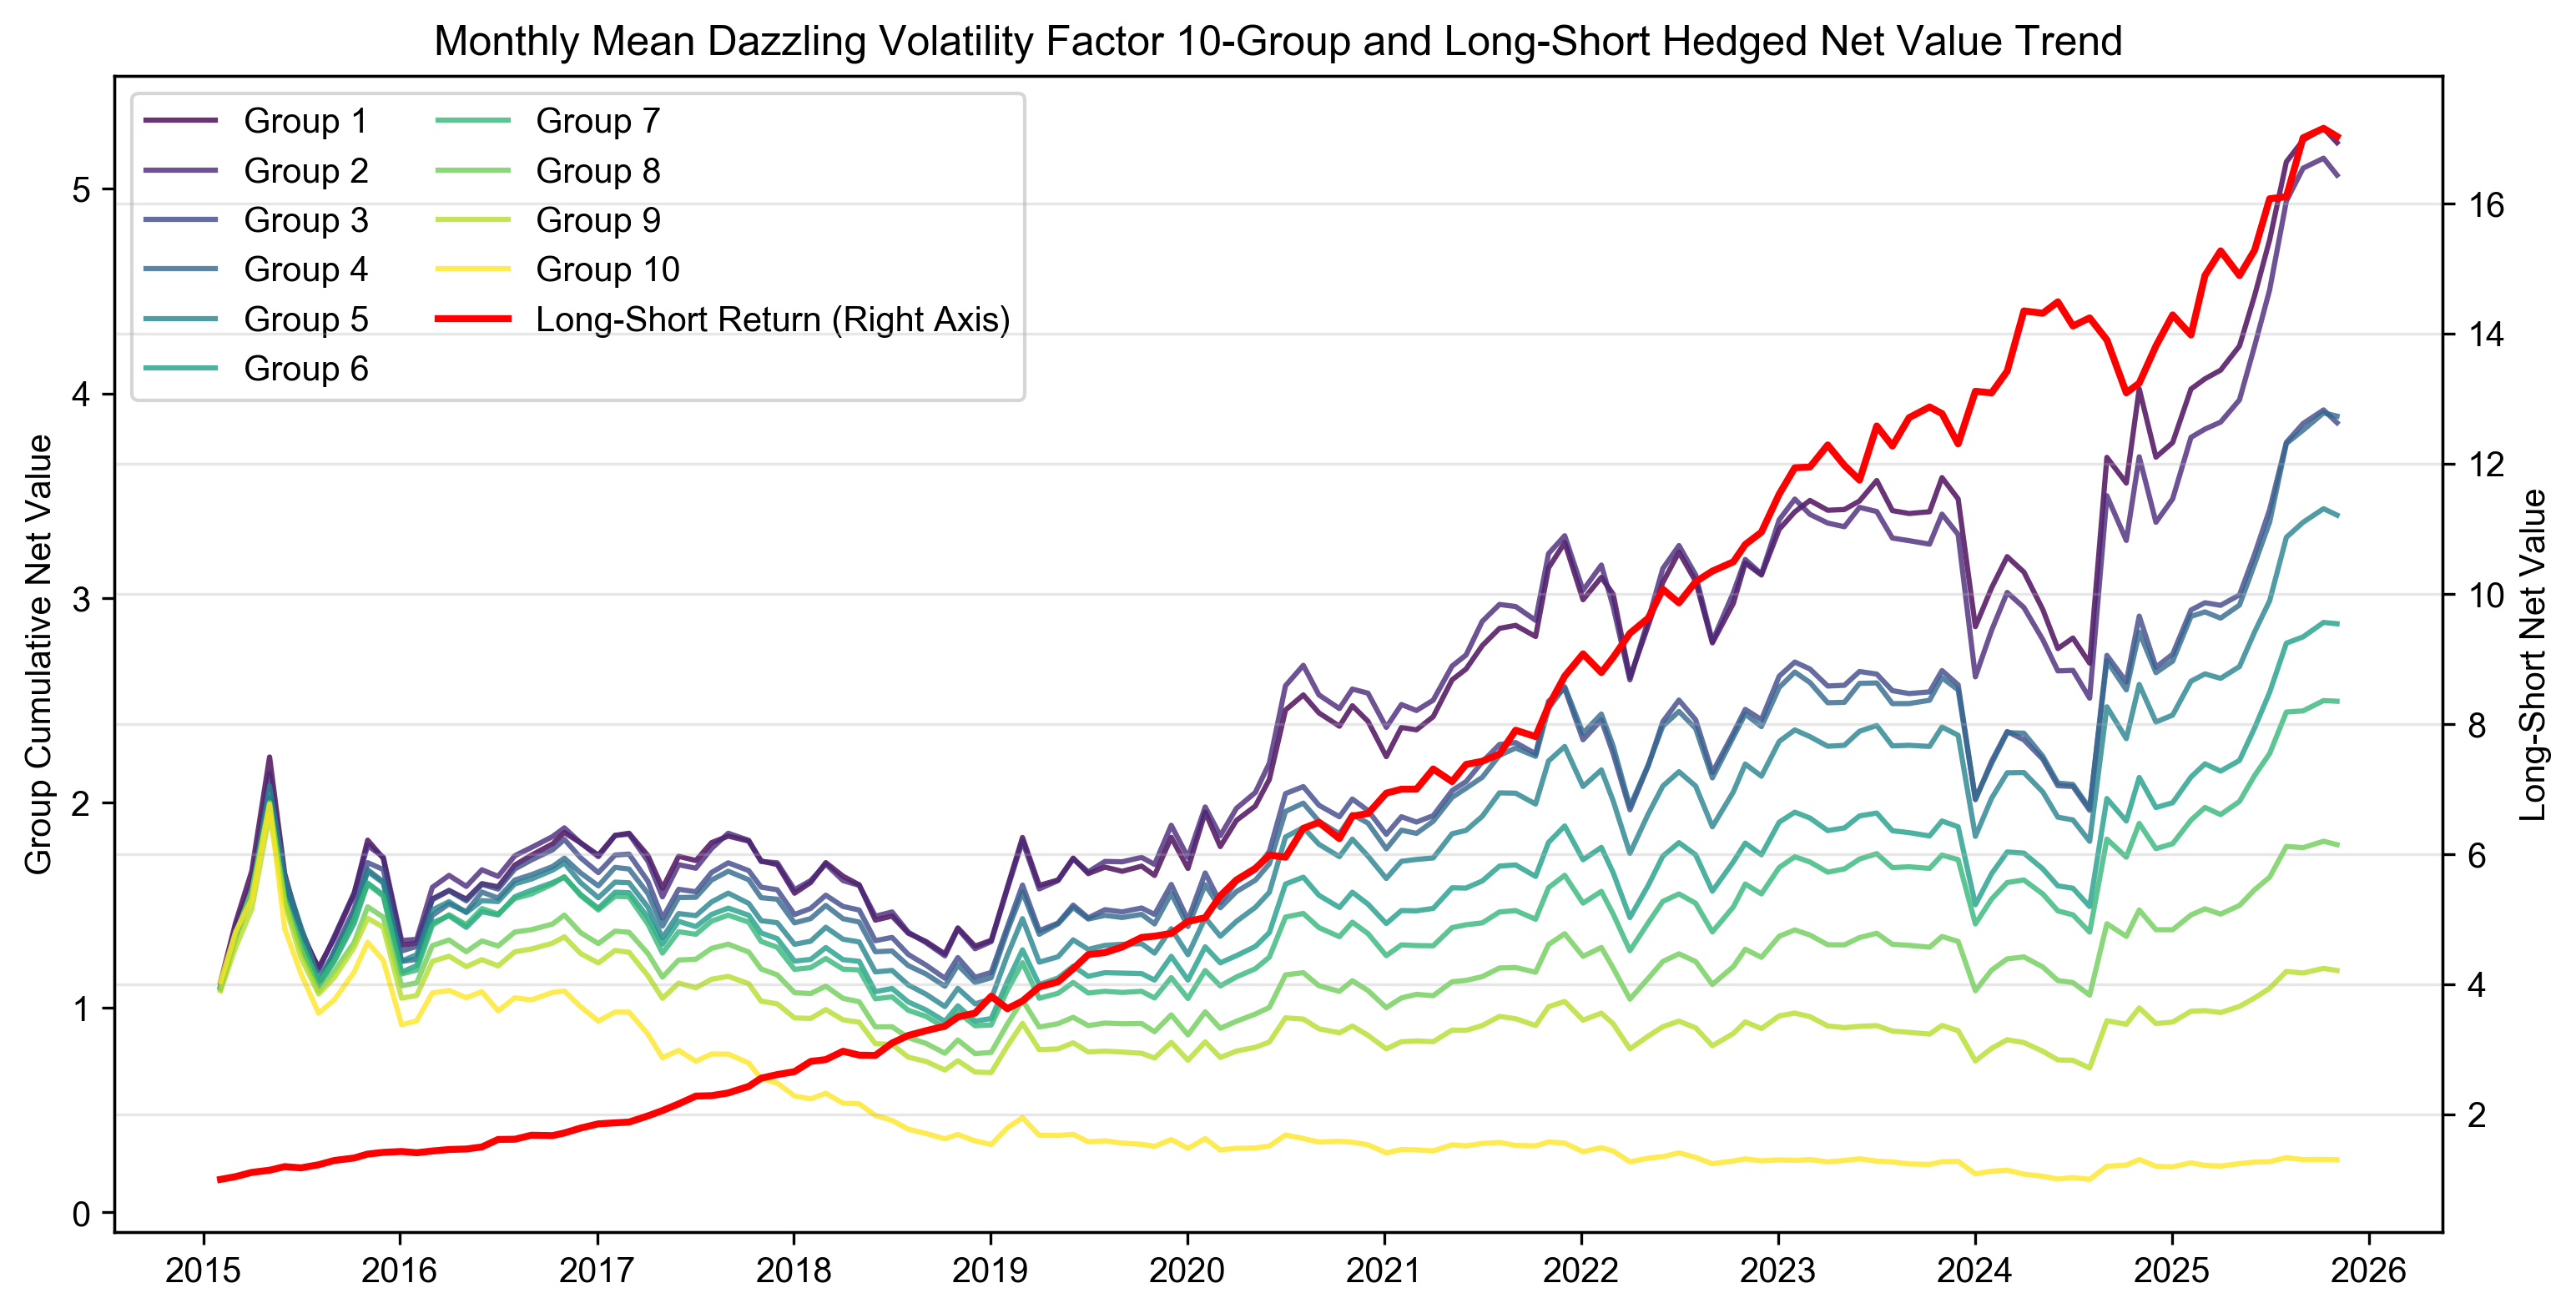

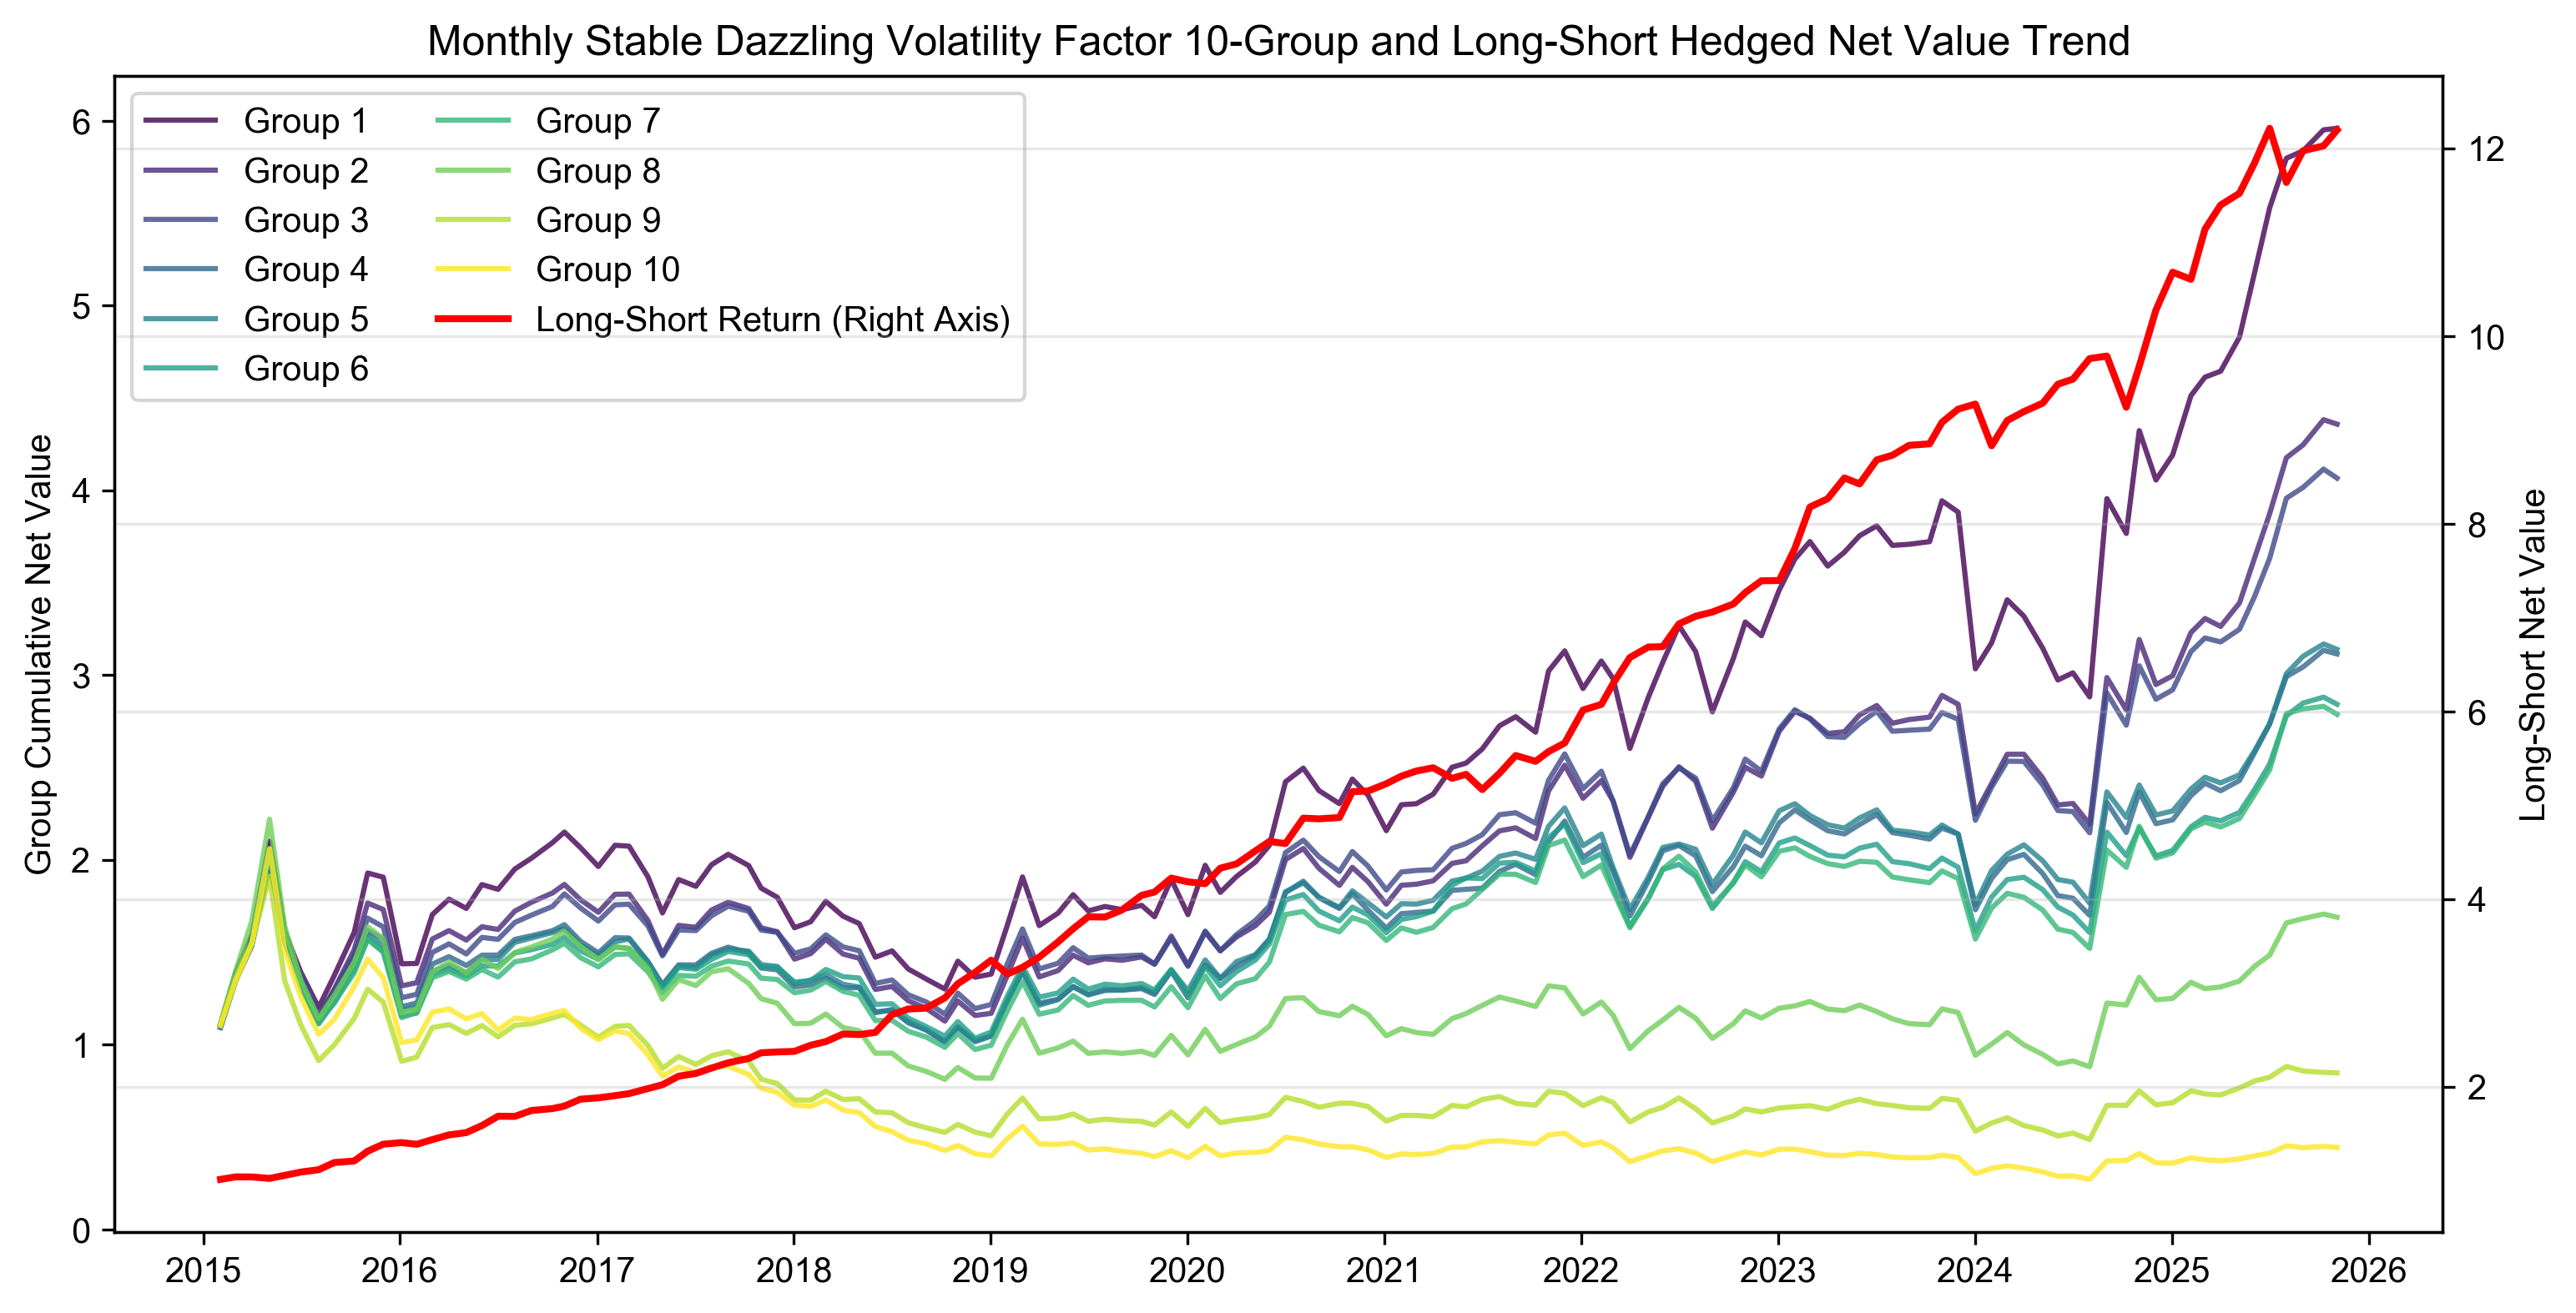

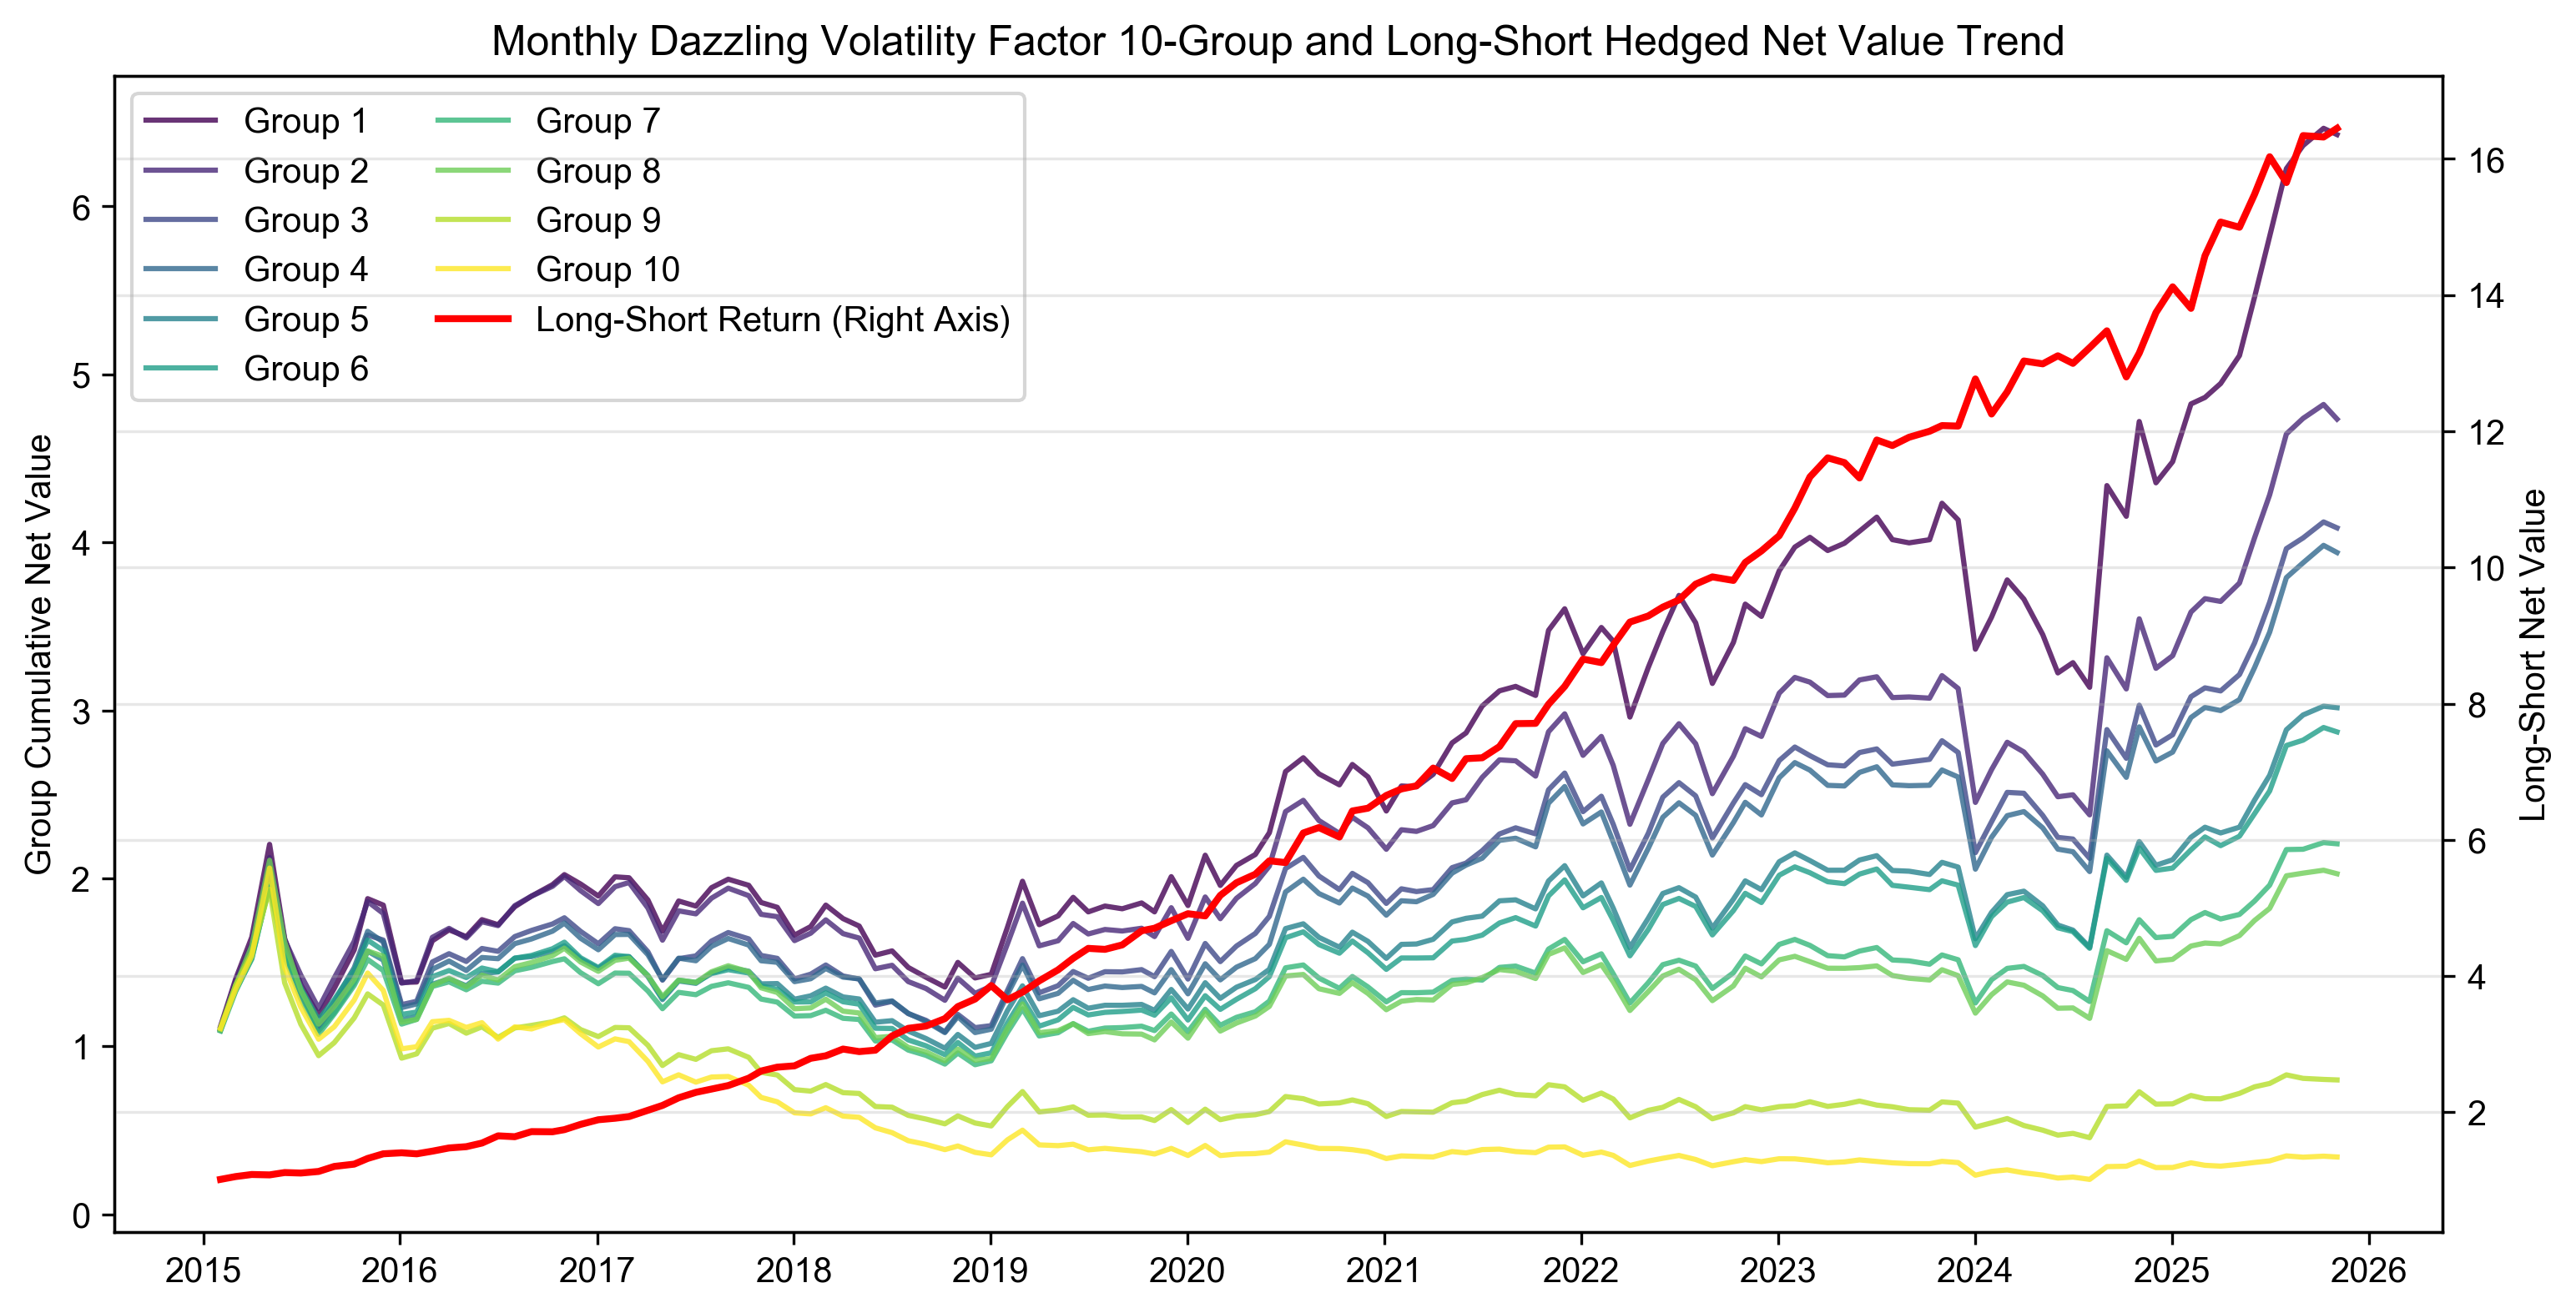

In [13]:
e1 = FactorBacktester(factor_monthly_mean_dazzling_vol_neutralized, stock_daily, factor_name='Monthly Mean Dazzling Volatility Factor')
e2 = FactorBacktester(factor_monthly_stability_dazzling_vol_neutralized, stock_daily, factor_name='Monthly Stable Dazzling Volatility Factor')
e3 = FactorBacktester(factor_monthly_dazzling_volatility_neutralized, stock_daily, factor_name='Monthly Dazzling Volatility Factor')

# Run backtests
for e in [e1, e2, e3]: e.run()
summary = show_factor_metrics(e1, e2, e3)
display(summary)

e1.plot_performance()
e2.plot_performance()
e3.plot_performance()

## Price Changes at Surge Moments

Next, we examine the price changes triggered by volume surges to construct the **"Monthly Mean Dazzling Return"** and **"Monthly Stable Dazzling Return"** factors. The specific process is as follows:

1. **Calculation**: Using the minute-level closing prices, we calculate the return for each minute of the stock.
2. **Dazzling Return**: We identify the minute returns corresponding to the "Surge Moments." For instance, in the previous example, if minutes 9, 10, 88, and 200 are surge moments, their respective returns are extracted and defined as **"Dazzling Returns."**
3. **Daily Dazzling Return**: We calculate the mean of all "Dazzling Returns" for stock A within day  as the proxy for the price reaction to volume surges at the return level, denoted as **"Daily Dazzling Return."**
4. **Moderate Daily Dazzling Return**: Based on the same logic used previously, we look for "Dazzling Returns" that are neither too high nor too low—ideally "moderate." Therefore, we subtract the cross-sectional mean from each stock's "Daily Dazzling Return" and take the absolute value. This represents the distance between an individual stock's "Daily Dazzling Return" and the market average, denoted as **"Moderate Daily Dazzling Return."**
5. **Monthly Aggregation**: We calculate the mean and standard deviation of the "Moderate Daily Dazzling Return" over the past 20 trading days, naming them the **"Monthly Mean Dazzling Return"** and **"Monthly Stable Dazzling Return"** factors, respectively.
6. **Factor Synthesis**: The **"Monthly Dazzling Return"** factor is obtained by equal-weighting the "Monthly Mean Dazzling Return" and "Monthly Stable Dazzling Return" factors.

In [14]:
# Path Settings
minute_data_path = '/Users/zhaoweizhi/Desktop/Quant_Research/Data/stock_1min/'
all_ts_codes = stock_daily.index.get_level_values('ts_code').unique()

# Storage for the calculated "Daily Dazzling Return" for each stock
daily_dazzling_ret_list = []

print("Starting to construct the Dazzling Return factor series...")

# Iterate through all stocks
for idx, ts_code in enumerate(all_ts_codes, 1):
    print(f"\rProcessing stock {idx}/{len(all_ts_codes)}: {ts_code}          ", end="")
    
    file_path = os.path.join(minute_data_path, f"{ts_code}.parquet")
    if not os.path.exists(file_path):
        continue
        
    df_min = pd.read_parquet(file_path)
    df_min = df_min.loc['2015-01-01':].copy()
    if df_min.empty:
        continue

    # 1. Minute-frequency backward adjustment processing
    latest_adj = df_min['adj_factor'].iloc[-1]
    mult = df_min['adj_factor'] / latest_adj
    df_min['close_adj'] = (df_min['close'] * mult).round(2)

    # 2. Calculate minute returns (groupby ensures exclusion of overnight gaps)
    df_min['min_ret'] = df_min.groupby(level='trade_date')['close_adj'].pct_change()

    # 3. Calculate volume surge moments (vol_delta)
    df_min['vol_delta'] = df_min.groupby(level='trade_date')['vol'].diff()
    # Calculate daily mean and standard deviation of volume changes
    daily_stats = df_min.groupby(level='trade_date')['vol_delta'].agg(['mean', 'std'])
    df_min = df_min.join(daily_stats, on='trade_date')
    
    # Define surge moments as delta > mean + 1 * std
    df_min['is_surge'] = (df_min['vol_delta'] > (df_min['mean'] + df_min['std'])).astype(int)

    # 4. Calculate "Daily Dazzling Return"
    # Extract the return of the specific surge minute and average by day
    factor_daily_dazzling_ret = df_min[df_min['is_surge'] == 1].groupby(level='trade_date')['min_ret'].mean()
    daily_dazzling_ret_list.append(factor_daily_dazzling_ret.to_frame(name=ts_code))

print("\n\nIndividual stock calculations complete, starting cross-sectional synthesis...")

# 5. Merge matrix
matrix_daily_dazzling_ret = pd.concat(daily_dazzling_ret_list, axis=1).sort_index()

# 6. Calculate "Moderate Daily Dazzling Return" (subtract cross-sectional mean and take absolute value)
section_mean_ret = matrix_daily_dazzling_ret.mean(axis=1)
factor_moderate_daily_dazzling_ret = matrix_daily_dazzling_ret.sub(section_mean_ret, axis=0).abs()

# 7. Calculate monthly factors (20-day rolling window)
# Monthly Mean Dazzling Return
factor_monthly_mean_dazzling_ret = factor_moderate_daily_dazzling_ret.rolling(20).mean()
# Monthly Stable Dazzling Return
factor_monthly_stability_dazzling_ret = factor_moderate_daily_dazzling_ret.rolling(20).std()

# 8. Final equal-weight synthesis for the "Monthly Dazzling Return" factor
factor_monthly_dazzling_ret = (factor_monthly_mean_dazzling_ret + factor_monthly_stability_dazzling_ret) / 2

print("Factor construction successful!")

Starting to construct the Dazzling Return factor series...
Processing stock 5701/5701: 920045.BJ          

Individual stock calculations complete, starting cross-sectional synthesis...
Factor construction successful!


100%|██████████| 2655/2655 [00:32<00:00, 82.42it/s]


Factor Name,Rank IC,Rank ICIR,t-stat,Annualized Return,Annualized Volatility,Information Ratio,Monthly Win Rate,Max Drawdown
Monthly Mean Dazzling Return Factor,-9.60%,-1.27,-14.46,27.15%,10.77%,2.52,80.00%,7.78%
Monthly Stable Dazzling Return Factor,-8.89%,-1.37,-15.57,22.47%,8.44%,2.66,80.00%,4.97%
Monthly Dazzling Return Factor,-9.37%,-1.33,-15.16,26.08%,9.43%,2.77,81.54%,6.01%


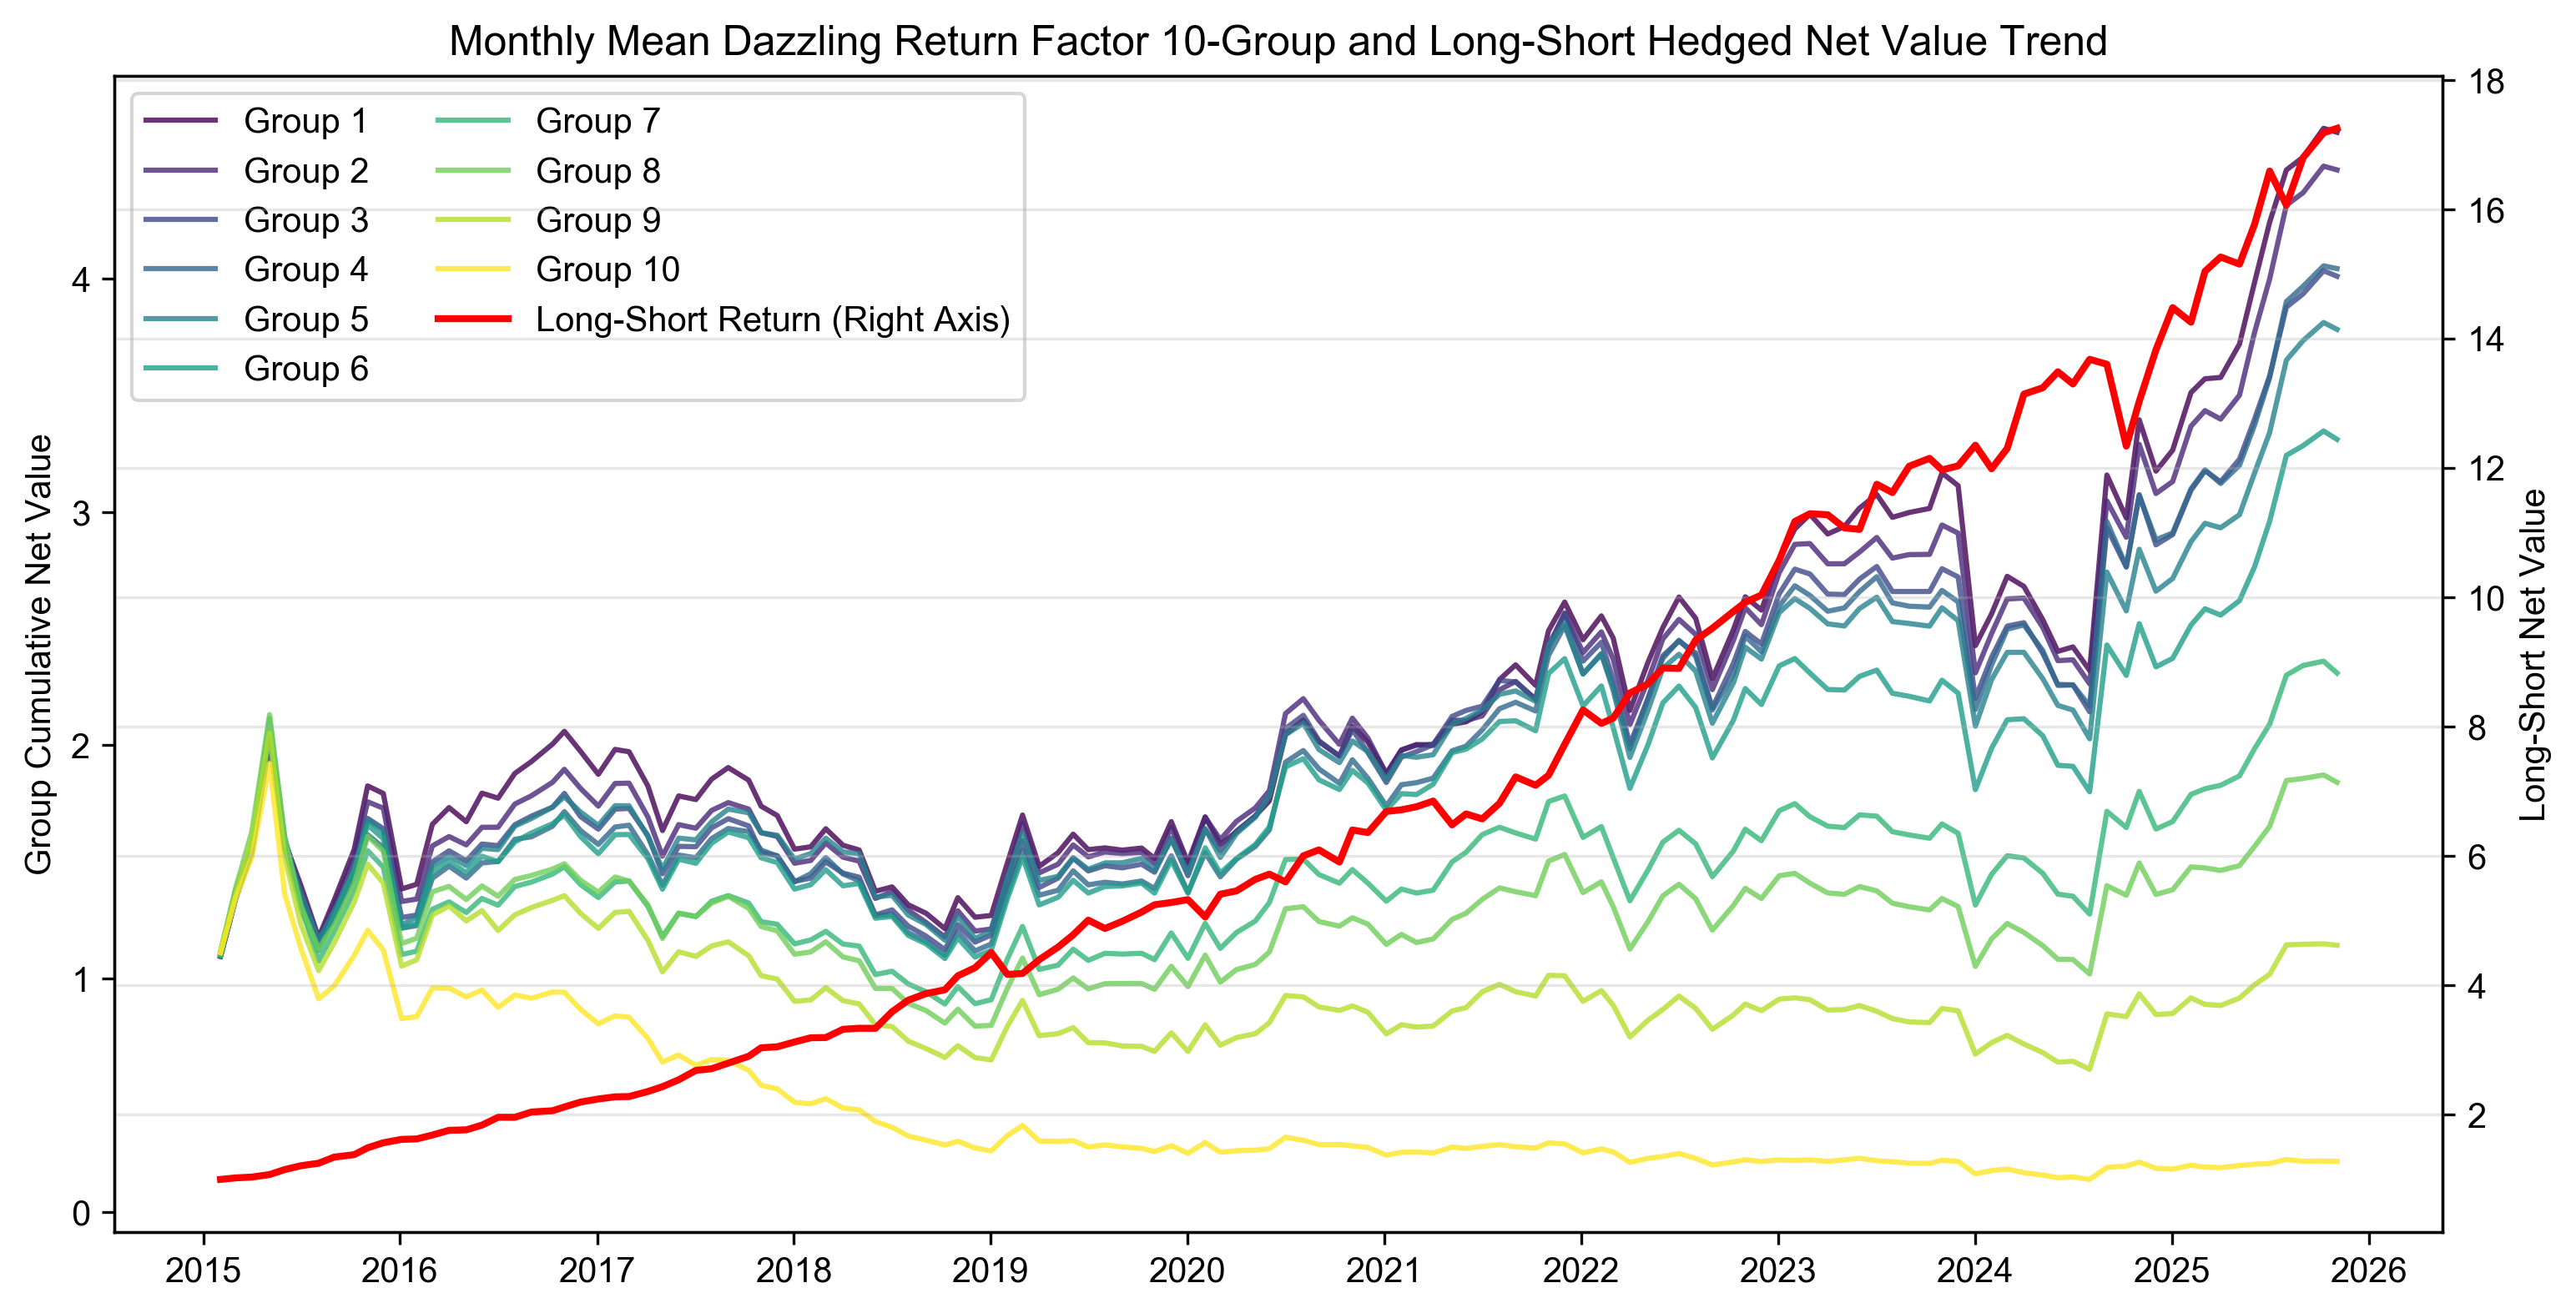

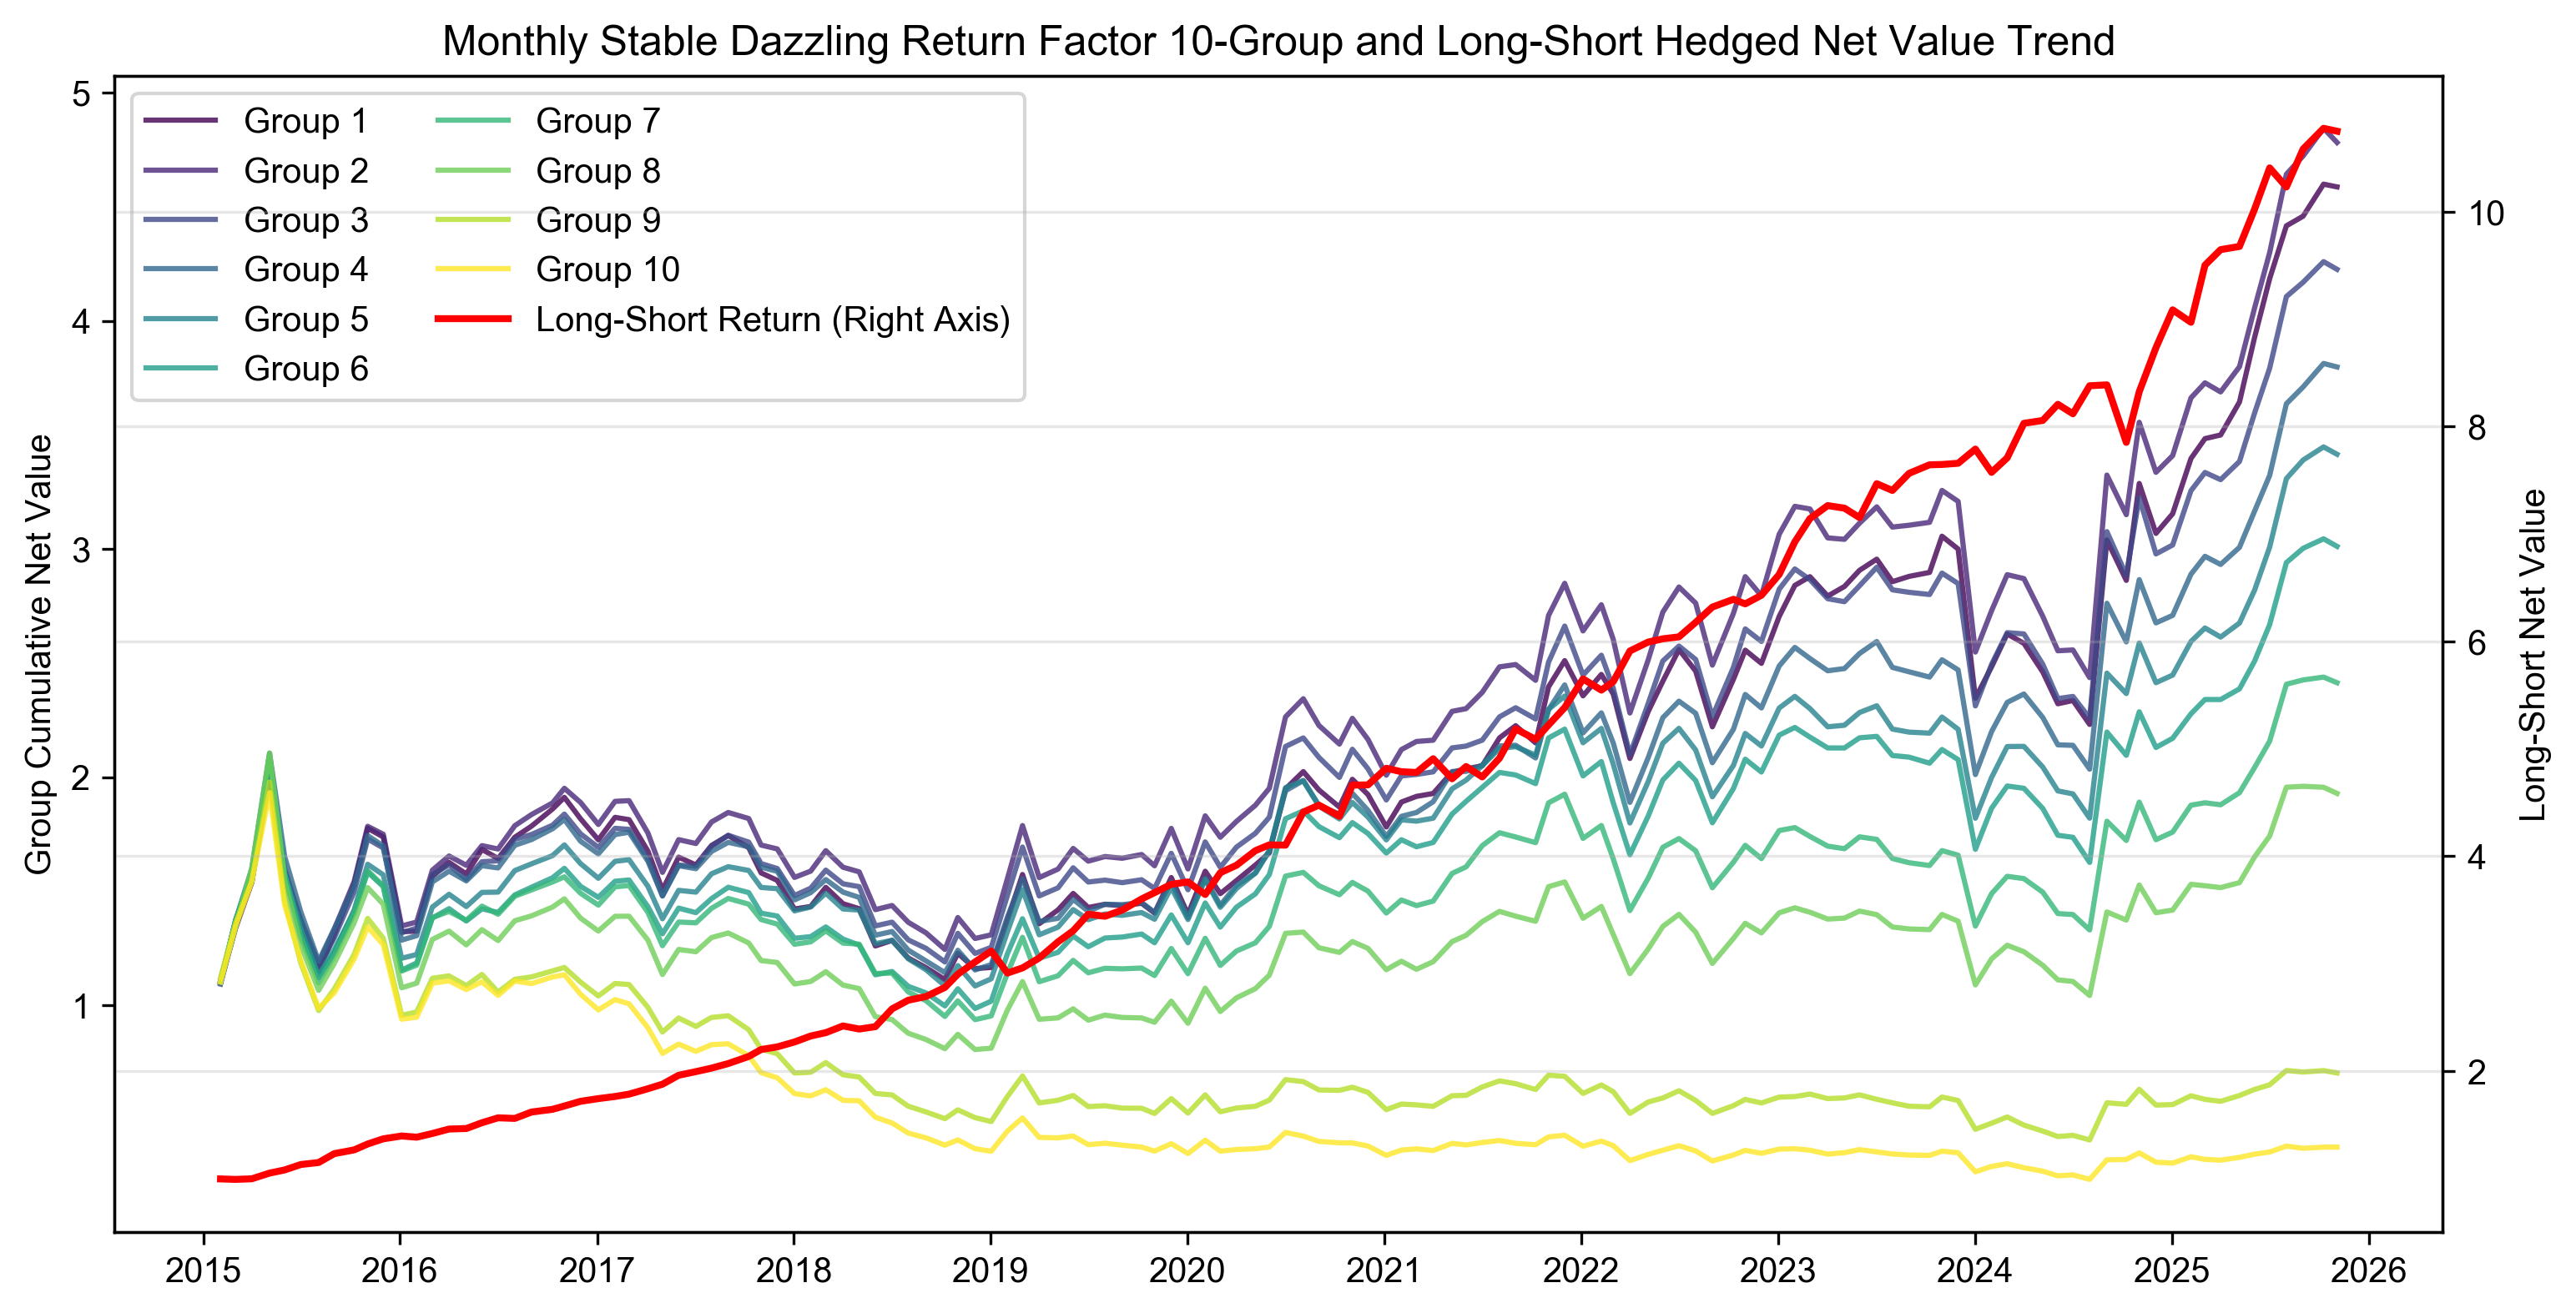

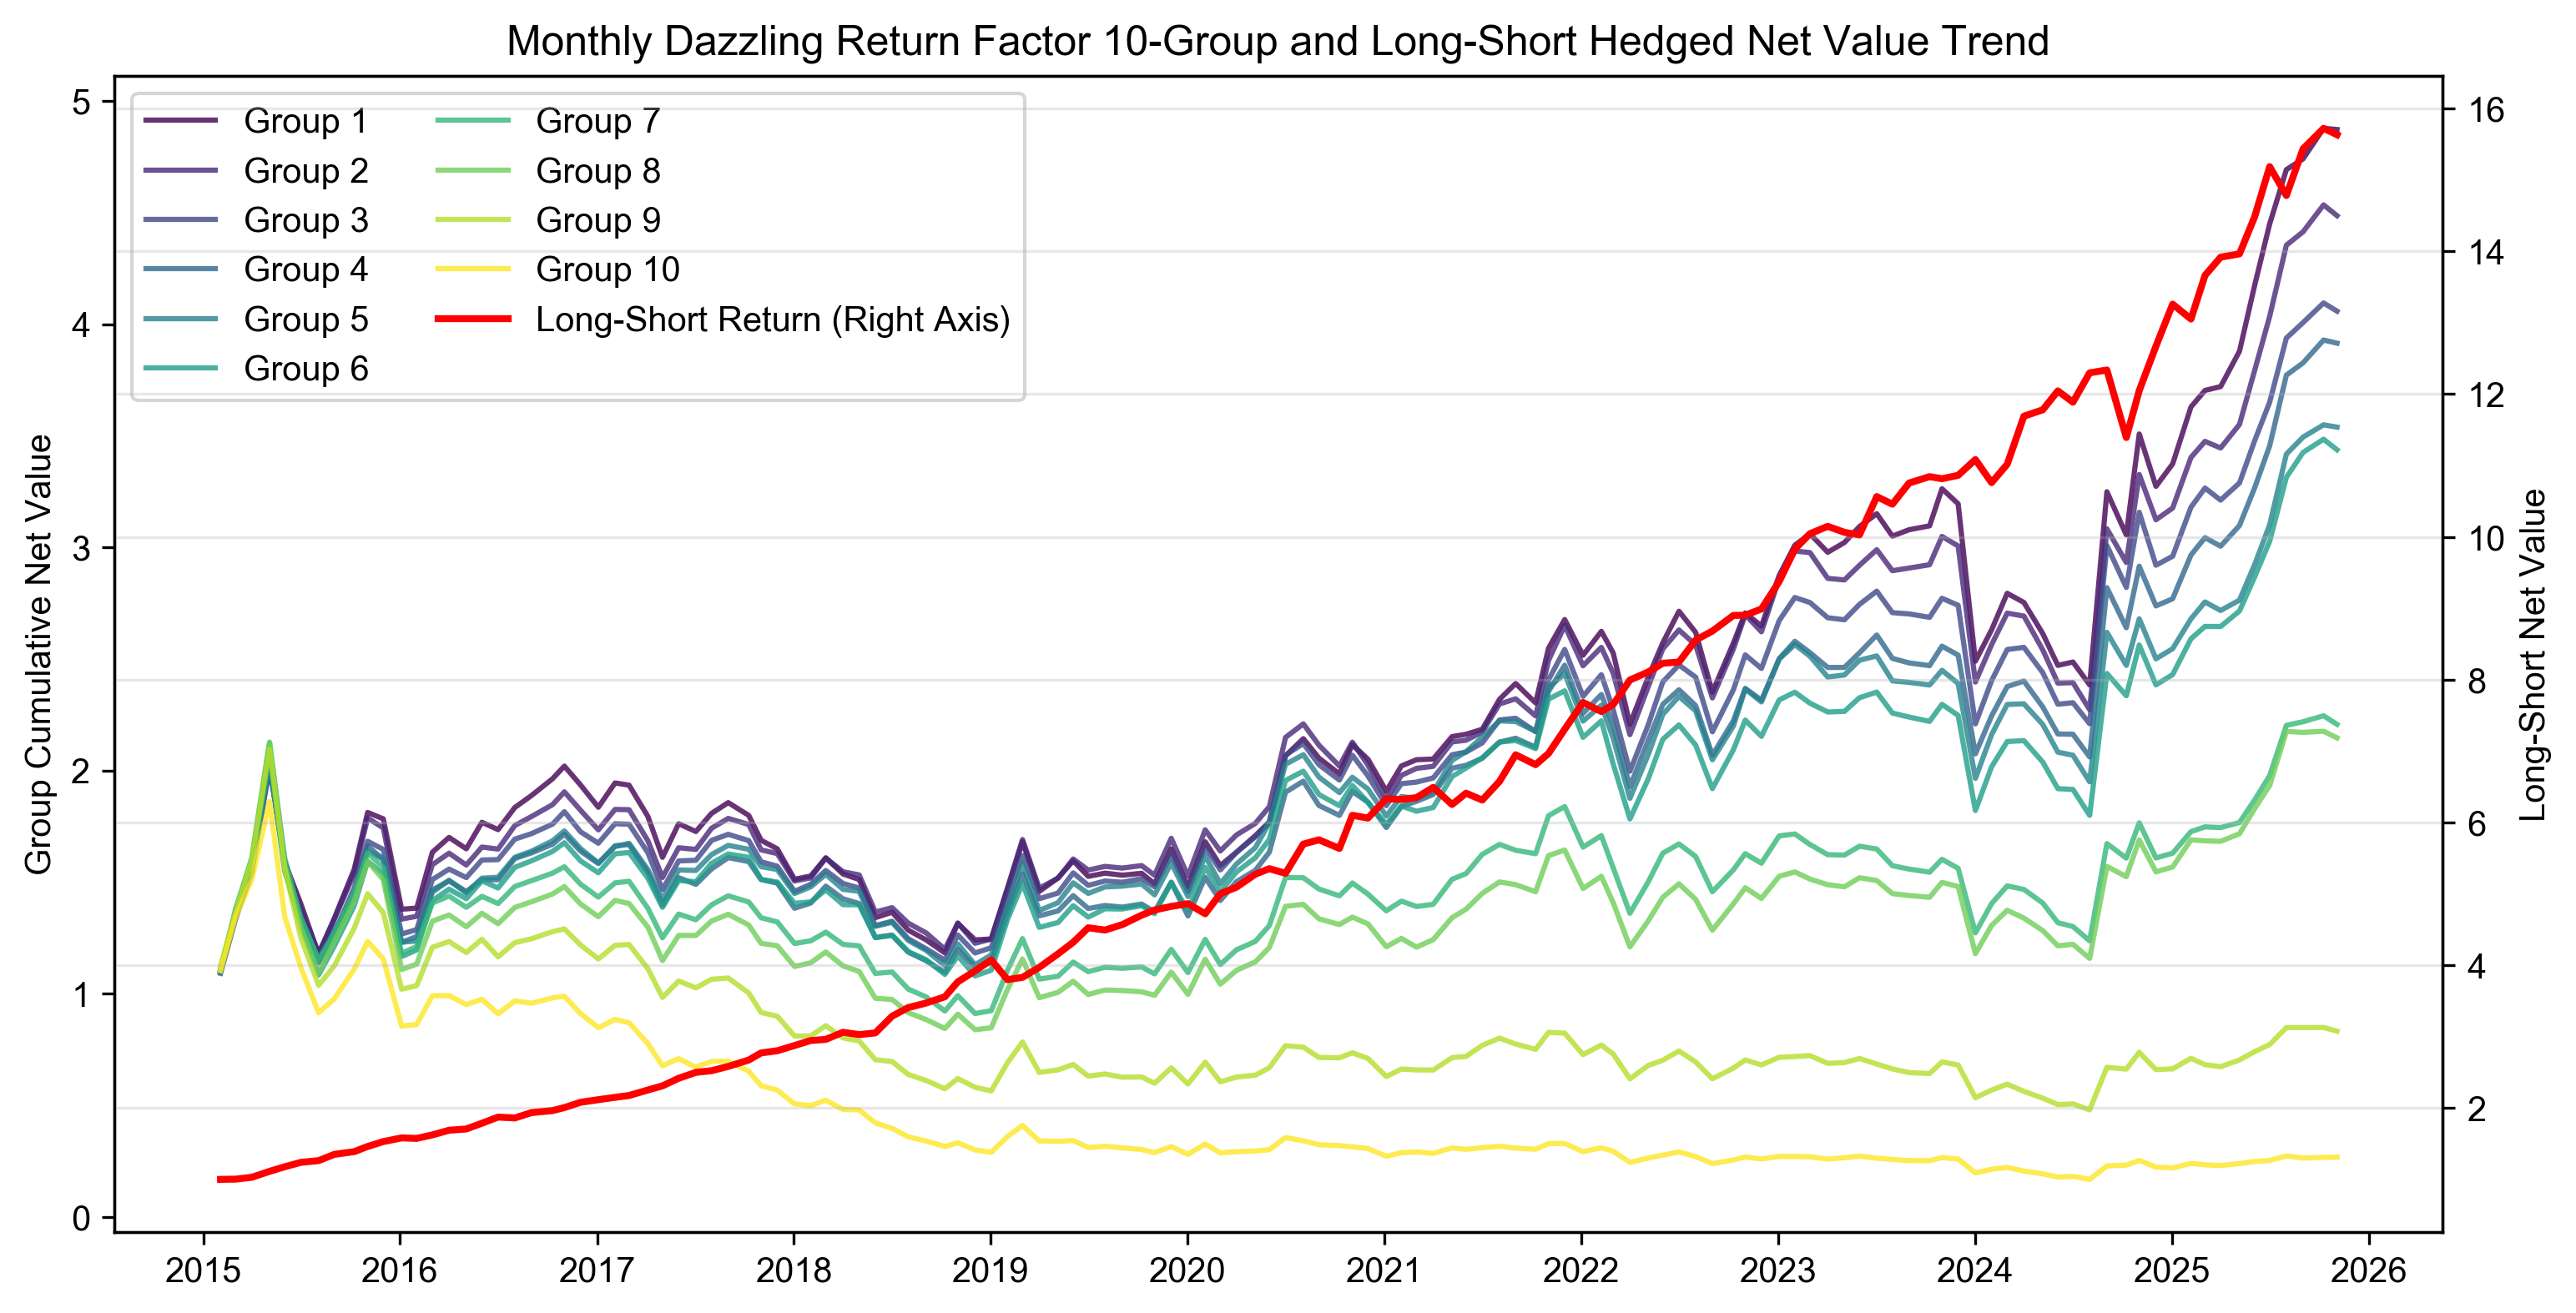

In [15]:
# After calculating the synthetic factors, drop rows that are entirely empty for each
factor_monthly_mean_dazzling_ret.dropna(how='all', axis=0, inplace=True)
factor_monthly_stability_dazzling_ret.dropna(how='all', axis=0, inplace=True)
factor_monthly_dazzling_ret.dropna(how='all', axis=0, inplace=True)

# Perform MAD winsorization, industry and market cap neutralization, and cross-sectional standardization on factors
# "Monthly Mean Dazzling Return" factor
factor_monthly_mean_dazzling_ret_neutralized = neutralize_factor(factor_monthly_mean_dazzling_ret, stock_daily) 
# "Monthly Stable Dazzling Return" factor
factor_monthly_stability_dazzling_ret_neutralized = neutralize_factor(factor_monthly_stability_dazzling_ret, stock_daily)
# "Monthly Dazzling Return" factor
factor_monthly_dazzling_ret_neutralized = neutralize_factor(factor_monthly_dazzling_ret, stock_daily)

e4 = FactorBacktester(factor_monthly_mean_dazzling_ret_neutralized, stock_daily, factor_name='Monthly Mean Dazzling Return Factor')
e5 = FactorBacktester(factor_monthly_stability_dazzling_ret_neutralized, stock_daily, factor_name='Monthly Stable Dazzling Return Factor')
e6 = FactorBacktester(factor_monthly_dazzling_ret_neutralized, stock_daily, factor_name='Monthly Dazzling Return Factor')

# Run backtests
for e in [e4, e5, e6]: e.run()
summary = show_factor_metrics(e4, e5, e6)
display(summary)

e4.plot_performance()
e5.plot_performance()
e6.plot_performance()

## Moderate Risk-Taking Factor Synthesis
Above, we have constructed two factors to measure "moderate risk-taking" from the perspectives of volatility and returns, respectively, and found that both possess very strong stock-selection capabilities. We now combine the aforementioned "Monthly Dazzling Volatility" factor and the "Monthly Dazzling Return" factor with equal weighting to synthesize the final "Moderate Risk-Taking" factor.

In [17]:
factor_monthly_moderate_adventure = (factor_monthly_dazzling_volatility_neutralized + factor_monthly_dazzling_ret_neutralized) / 2

In [18]:
factor_monthly_moderate_adventure

,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000007.SZ,000008.SZ,000011.SZ,000012.SZ,000014.SZ,000016.SZ,...,301449.SZ,301667.SZ,603248.SH,688805.SH,920121.BJ,001369.SZ,001396.SZ,688809.SH,301687.SZ,920045.BJ
trade_date,,,,,,,,,,,,,,,,,,,,,
2015-01-30,-0.731342,0.629386,-0.178257,-0.735095,-0.023245,-0.447539,0.029767,-0.787351,-0.691324,1.499744,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-02,-0.735259,0.407869,-0.043013,-0.587276,0.078469,-0.482256,0.141100,-0.763971,-0.628361,1.523164,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-03,-0.690726,0.292214,-0.059286,-0.611692,0.082264,-0.443780,0.193352,-0.710837,-0.594769,1.070334,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-04,-0.659422,0.281752,-0.070477,-0.601590,0.066736,-0.668560,0.228501,-0.691143,-0.565115,1.012811,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-05,-0.793218,0.980048,-0.121924,-0.669950,0.000102,-0.707575,0.377729,-0.712264,-0.581203,1.061044,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-25,0.178932,0.092548,-0.580097,-1.010275,-0.536036,-0.862705,-0.934894,-1.002731,-0.631950,1.379778,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-26,0.174449,0.048733,-0.570526,-1.015374,-0.527747,-0.867090,-0.901663,-1.010098,-0.603015,1.418153,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-29,0.178422,-0.008605,-0.587900,-1.211106,-1.366928,-0.883670,-0.939203,-1.023900,-0.607868,1.401856,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Factor Name,Rank IC,Rank ICIR,t-stat,Annualized Return,Annualized Volatility,Information Ratio,Monthly Win Rate,Max Drawdown
Moderate Risk-Taking Factor,-9.34%,-1.48,-16.92,29.86%,9.20%,3.25,83.85%,4.53%


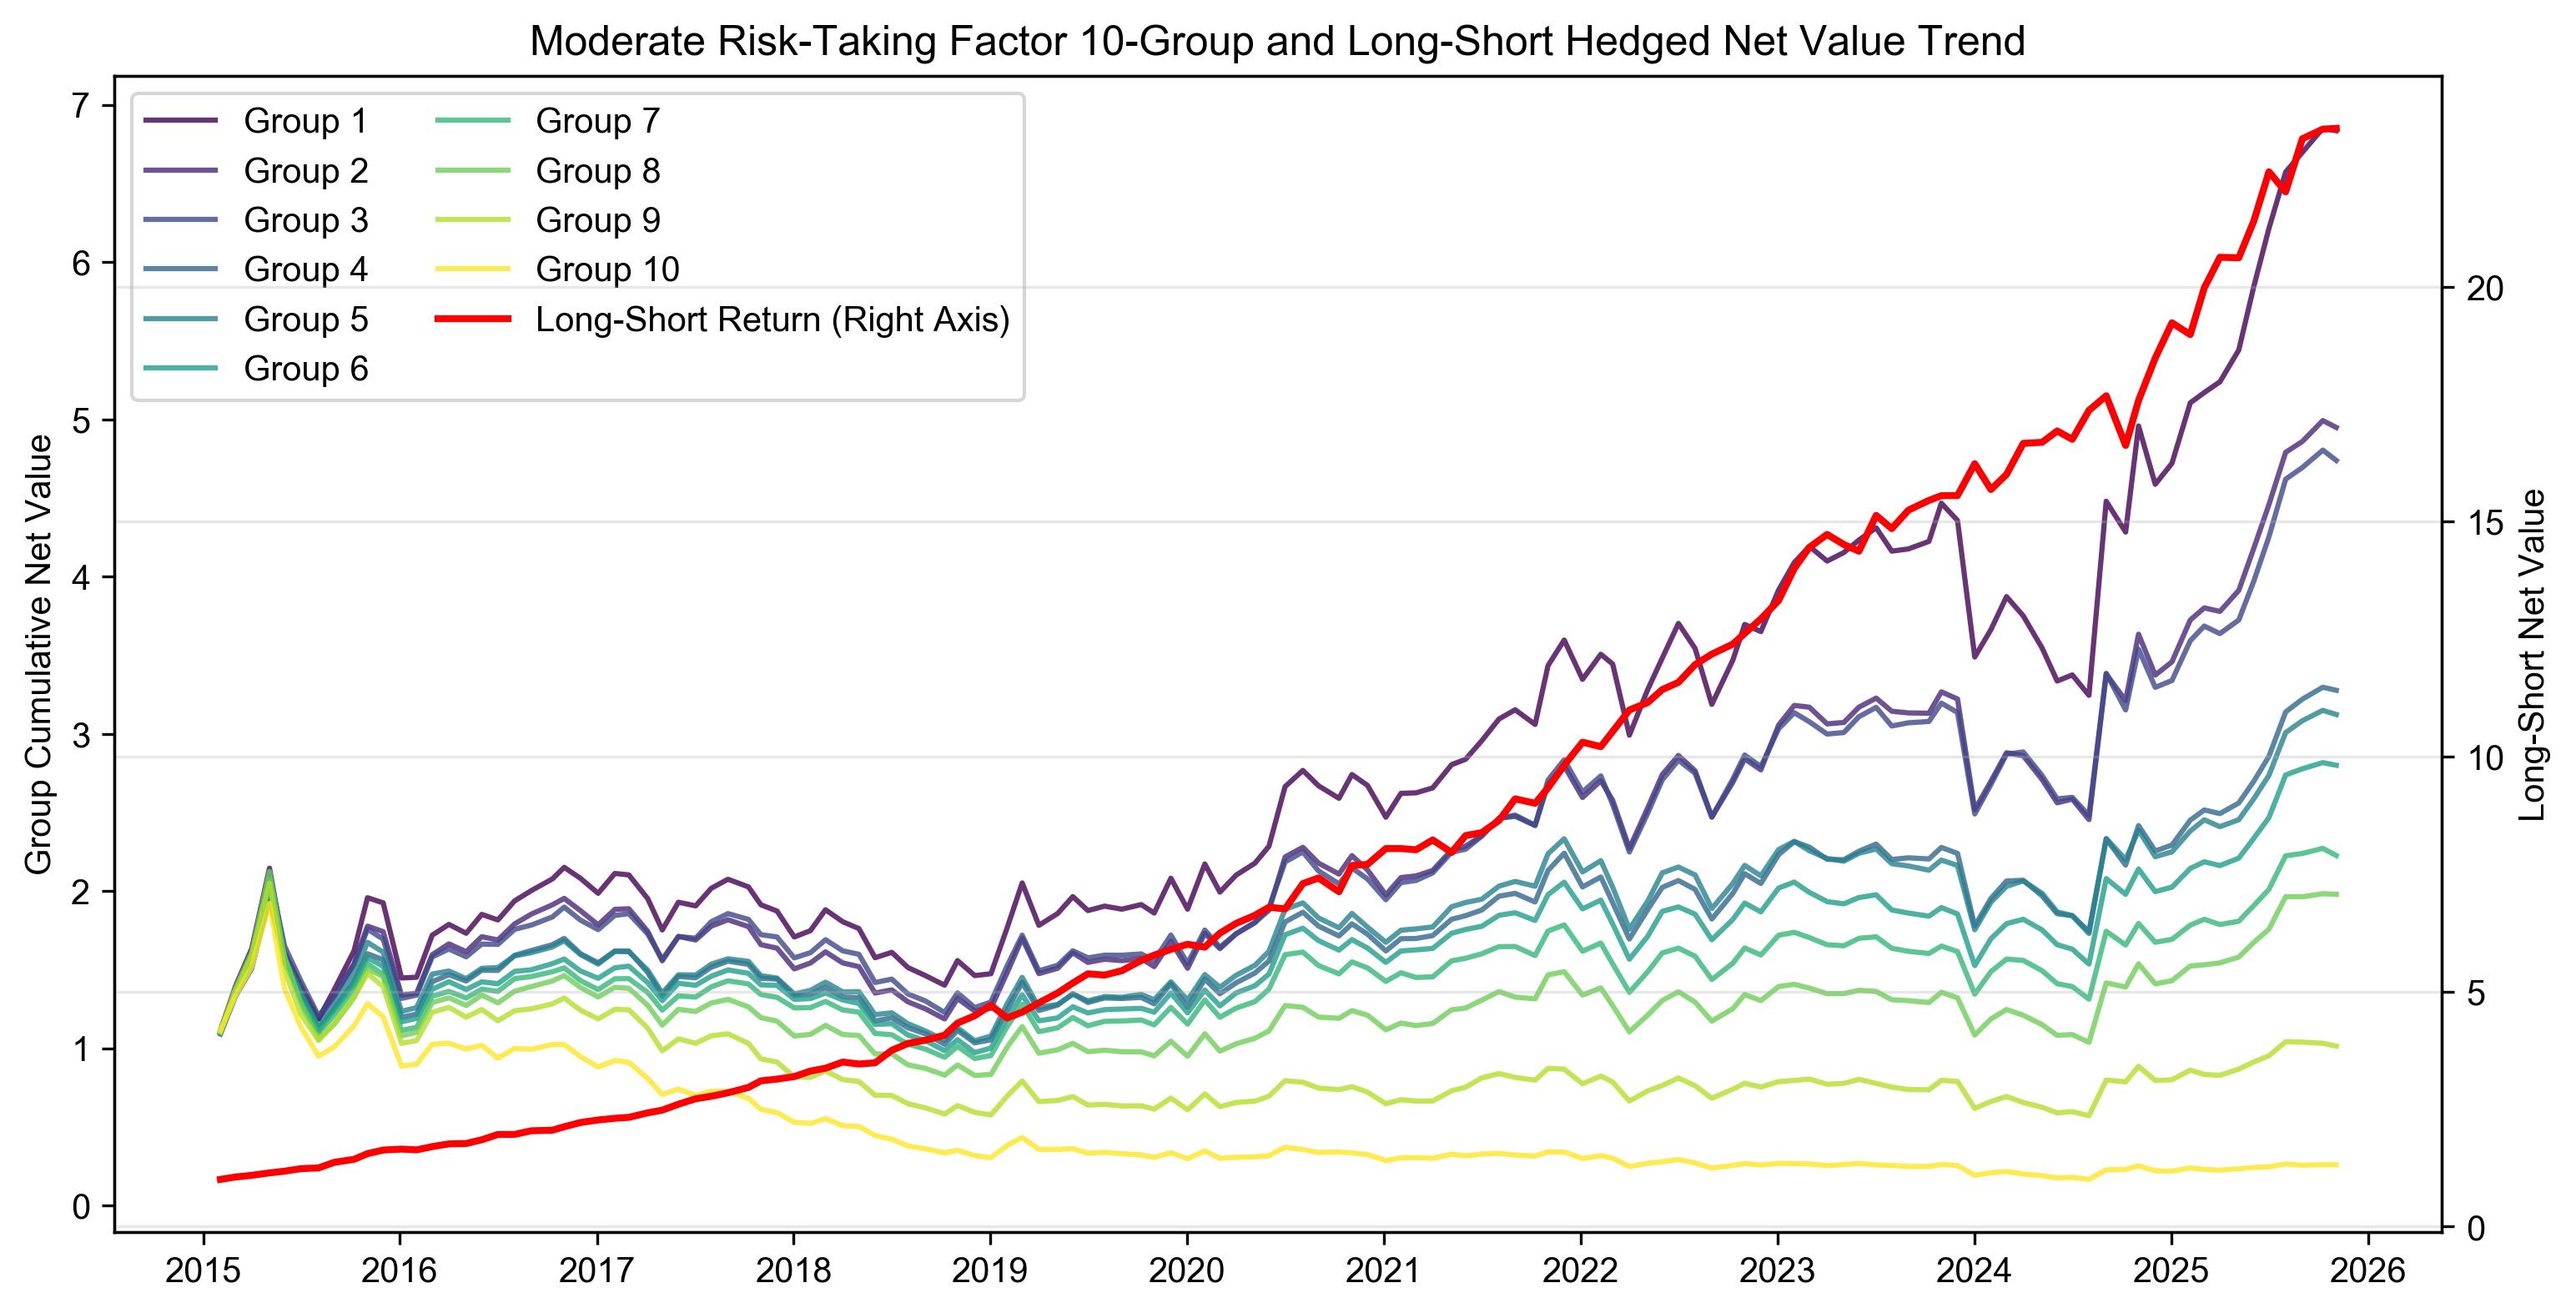

In [19]:
e7 = FactorBacktester(factor_monthly_moderate_adventure, stock_daily, factor_name='Moderate Risk-Taking Factor')
# Run backtest
e7.run()
summary = show_factor_metrics(e7)
display(summary)

e7.plot_performance()

## "Moderate Risk-Taking" Factor Still Performs Well After Stripping Other Style Factor Influences

From the above test results, the "Moderate Risk-Taking" factor demonstrates excellent stock-selection capability. Furthermore, we tested its correlation with other common style factors. As shown in the figure below, the "Moderate Risk-Taking" factor has some correlation with Liquidity, Reversal, and Volatility factors, while the correlation coefficients with other style factors are relatively low. To further verify the incremental information of the factor, we use 10 common style factors to orthogonalize the "Moderate Risk-Taking" factor, obtaining the "Pure Moderate Risk-Taking" factor, and then re-examine its stock-selection capability.

In [20]:
# 1. Prepare wide-format data (based on adjusted prices)
close = stock_daily['close'].unstack()
pct_chg = stock_daily['pct_chg'].unstack() / 100  # Convert percentage change to decimal
turnover = stock_daily['turnover_rate'].unstack()
pb = stock_daily['pb'].unstack()
total_mv = stock_daily['total_mv'].unstack()

# 2. Core style factor calculation
# (1) Size Factor (Size): Natural log of total market capitalization
factor_size = np.log(total_mv)

# (2) Non-linear Size Factor (NLSize): Cube of the log market capitalization
# This captures non-linear components that the standard Size factor cannot explain during orthogonalization
factor_nlsize = factor_size ** 3

# (3) Value Factor (Value): Book-to-Market ratio (BP)
# Valuation in reports usually refers to BP, which is the reciprocal of PB
factor_value = 1 / pb

# (4) Liquidity Factor (Liquidity): Average turnover rate over the past 20 trading days (approx. one month)
factor_liquidity = turnover.rolling(20, min_periods=10).mean()

# (5) Reversal Factor (Reversal): Cumulative return over the past 20 trading days
factor_reversal = close.pct_change(20)

# (6) Volatility Factor (Volatility): Standard deviation of daily returns over the past 60 trading days (approx. one quarter)
factor_volatility = pct_chg.rolling(60, min_periods=30).std()

# 3. Cross-sectional Standardization (Z-Score)
def standardize(df):
    """Standardize each row (cross-section) to have a mean of 0 and a standard deviation of 1"""
    return df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1), axis=0)

# Aggregate into a dictionary
style_factors = {
    'Size': standardize(factor_size),
    'NLSize': standardize(factor_nlsize),
    'Value': standardize(factor_value),
    'Liquidity': standardize(factor_liquidity),
    'Reversal': standardize(factor_reversal),
    'Volatility': standardize(factor_volatility)
}

print("Calculation of the 6 major style factors based on adjusted data is complete.")

Calculation of the 6 major style factors based on adjusted data is complete.


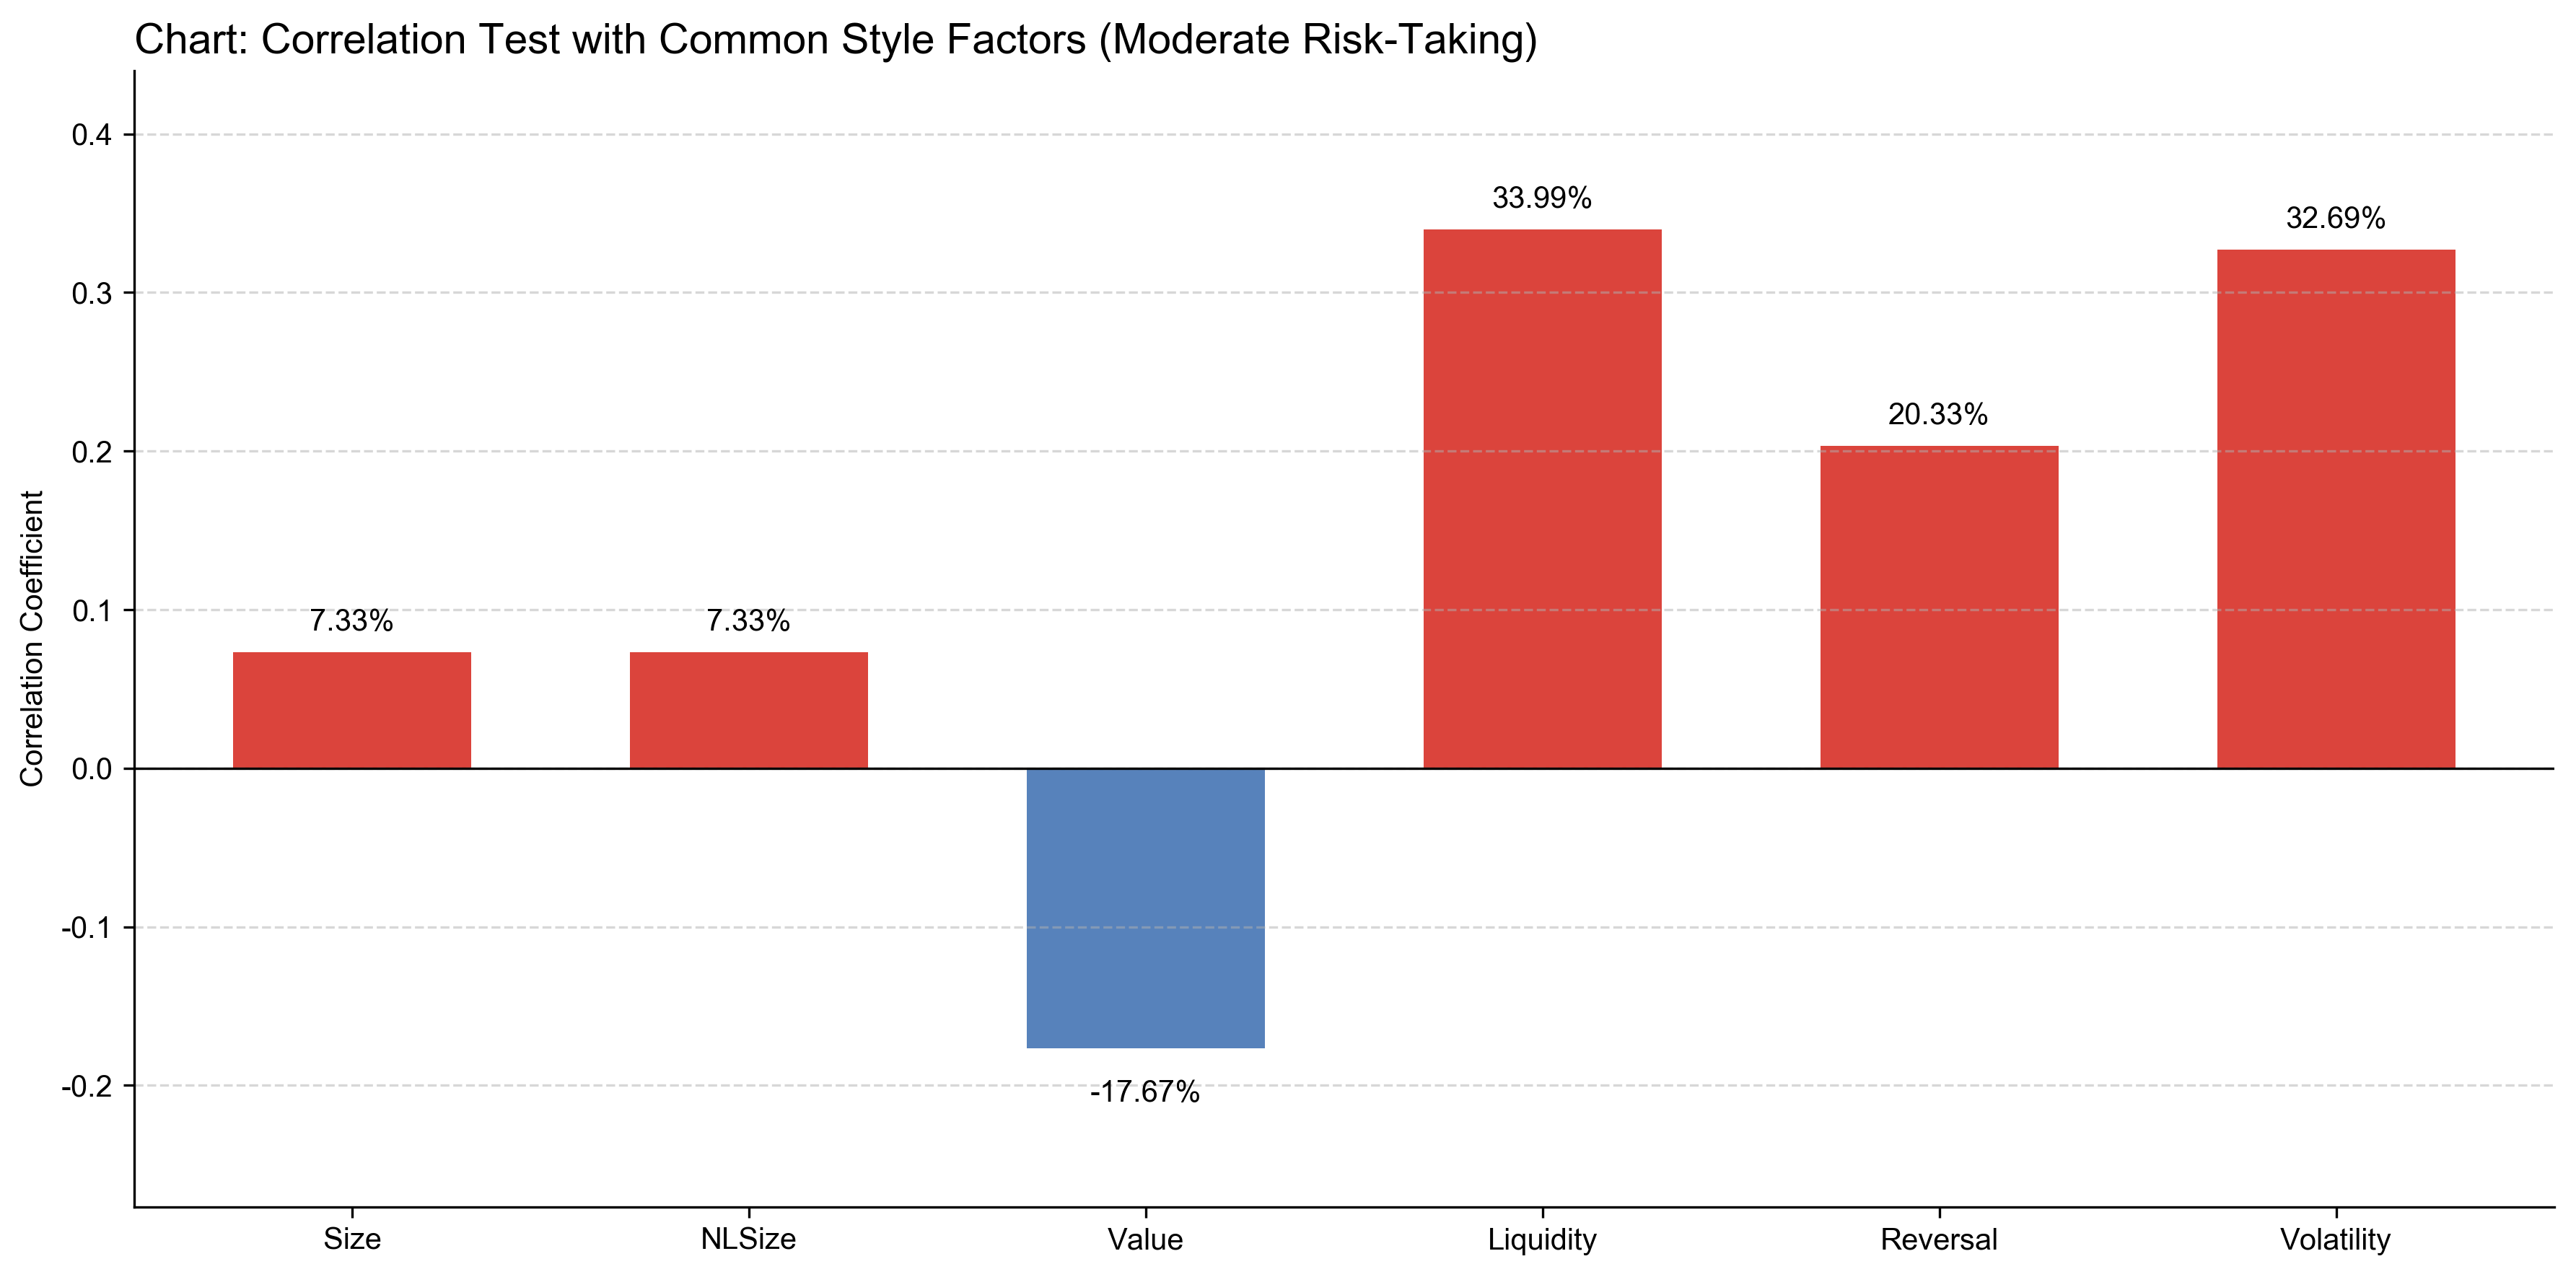

In [21]:
def plot_style_exposure_bar(target_factor, style_dict, target_name="Moderate Risk-Taking"):
    """
    Plot the exposure (correlation coefficient) of the target factor to each style factor as a bar chart.
    """
    exposure_res = {}
    
    # Calculate daily cross-sectional correlation
    for name, s_factor in style_dict.items():
        daily_corr = target_factor.corrwith(s_factor, axis=1, method='spearman')
        exposure_res[name] = daily_corr.mean()
    
    # Convert to Series and plot
    exposure_series = pd.Series(exposure_res)
    
    plt.figure(figsize=(12, 6), dpi=300)
    colors = ['#d73027' if v > 0 else '#4575b4' for v in exposure_series.values]
    
    ax = exposure_series.plot(kind='bar', color=colors, alpha=0.9, width=0.6)
    
    # Add percentage labels (mimicking the image)
    for i, v in enumerate(exposure_series.values):
        ax.text(i, v + (0.01 if v > 0 else -0.02), f"{v:.2%}", 
                ha='center', va='bottom' if v > 0 else 'top', fontsize=10)
    
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title(f"Chart: Correlation Test with Common Style Factors ({target_name})", loc='left', fontsize=14)
    plt.ylabel("Correlation Coefficient")
    plt.ylim(exposure_series.min() - 0.1, exposure_series.max() + 0.1)
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    sns.despine() # Remove top and right borders
    plt.tight_layout()
    plt.show()

# Show exposure before orthogonalization
plot_style_exposure_bar(factor_monthly_moderate_adventure, style_factors, "Moderate Risk-Taking")

In [22]:
def factor_orthogonalization(target_factor, style_factors_dict):
    """
    Perform style orthogonalization on the target factor, extracting residuals as the pure factor.
    """
    # Prepare matrix to store residuals
    pure_factor = pd.DataFrame(index=target_factor.index, columns=target_factor.columns)
    
    # Perform cross-sectional regression day by day
    for date in target_factor.index:
        # 1. Extract target factor values for the current day
        y = target_factor.loc[date].dropna()
        if y.empty: continue
        
        # 2. Extract values for each style factor for the current day
        X_dict = {name: df.loc[date] for name, df in style_factors_dict.items()}
        X = pd.DataFrame(X_dict).reindex(y.index)
        
        # 3. Align data and drop missing values
        combined = pd.concat([y, X], axis=1).dropna()
        if combined.empty: continue
        
        curr_y = combined.iloc[:, 0]
        curr_X = combined.iloc[:, 1:]
        curr_X = sm.add_constant(curr_X) # Add constant term
        
        # 4. Run regression and extract residuals
        model = sm.OLS(curr_y, curr_X).fit()
        pure_factor.loc[date, curr_y.index] = model.resid
    pure_factor.dropna(how='all', inplace=True)
    return pure_factor.astype(float)

# Execute orthogonalization: obtain the "Pure Moderate Risk-Taking" factor
factor_pure_adventure = factor_orthogonalization(factor_monthly_moderate_adventure, style_factors)

In [23]:
factor_pure_adventure

,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000007.SZ,000008.SZ,000011.SZ,000012.SZ,000014.SZ,000016.SZ,...,301449.SZ,301667.SZ,603248.SH,688805.SH,920121.BJ,001369.SZ,001396.SZ,688809.SH,301687.SZ,920045.BJ
trade_date,,,,,,,,,,,,,,,,,,,,,
2015-02-13,-0.194605,0.778032,-0.391046,-0.480907,0.719117,-0.196940,0.296483,-0.576975,-0.357373,1.732117,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-16,-0.144261,0.845584,-0.367002,-0.435821,0.705268,-0.157856,0.322234,-0.549097,-0.268023,1.635540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-17,-0.121975,0.655722,-0.299007,-0.345481,0.661997,-0.366726,0.337922,-0.573510,-0.249155,1.471620,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-25,0.003268,0.704038,-0.262314,-0.296395,0.751276,-0.382402,0.407920,-0.562641,-0.192642,1.148274,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-26,-0.031936,0.839644,-0.350355,-0.330751,0.475288,-0.252693,0.415128,-0.539321,-0.221794,1.258938,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-25,0.594416,0.425962,-0.491782,-0.769949,-0.911957,-0.535740,-0.453204,-0.569945,-0.593475,1.614165,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-26,0.613699,0.431179,-0.408219,-0.762547,-0.883452,-0.512567,-0.426382,-0.569870,-0.527960,1.668610,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-29,0.637130,0.392996,-0.353724,-0.984168,-1.585023,-0.544105,-0.489234,-0.575781,-0.555566,1.698997,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Factor Name,Rank IC,Rank ICIR,t-stat,Annualized Return,Annualized Volatility,Information Ratio,Monthly Win Rate,Max Drawdown
Pure Moderate Risk-Taking Factor,-5.03%,-0.82,-9.27,13.42%,10.26%,1.31,68.99%,8.90%


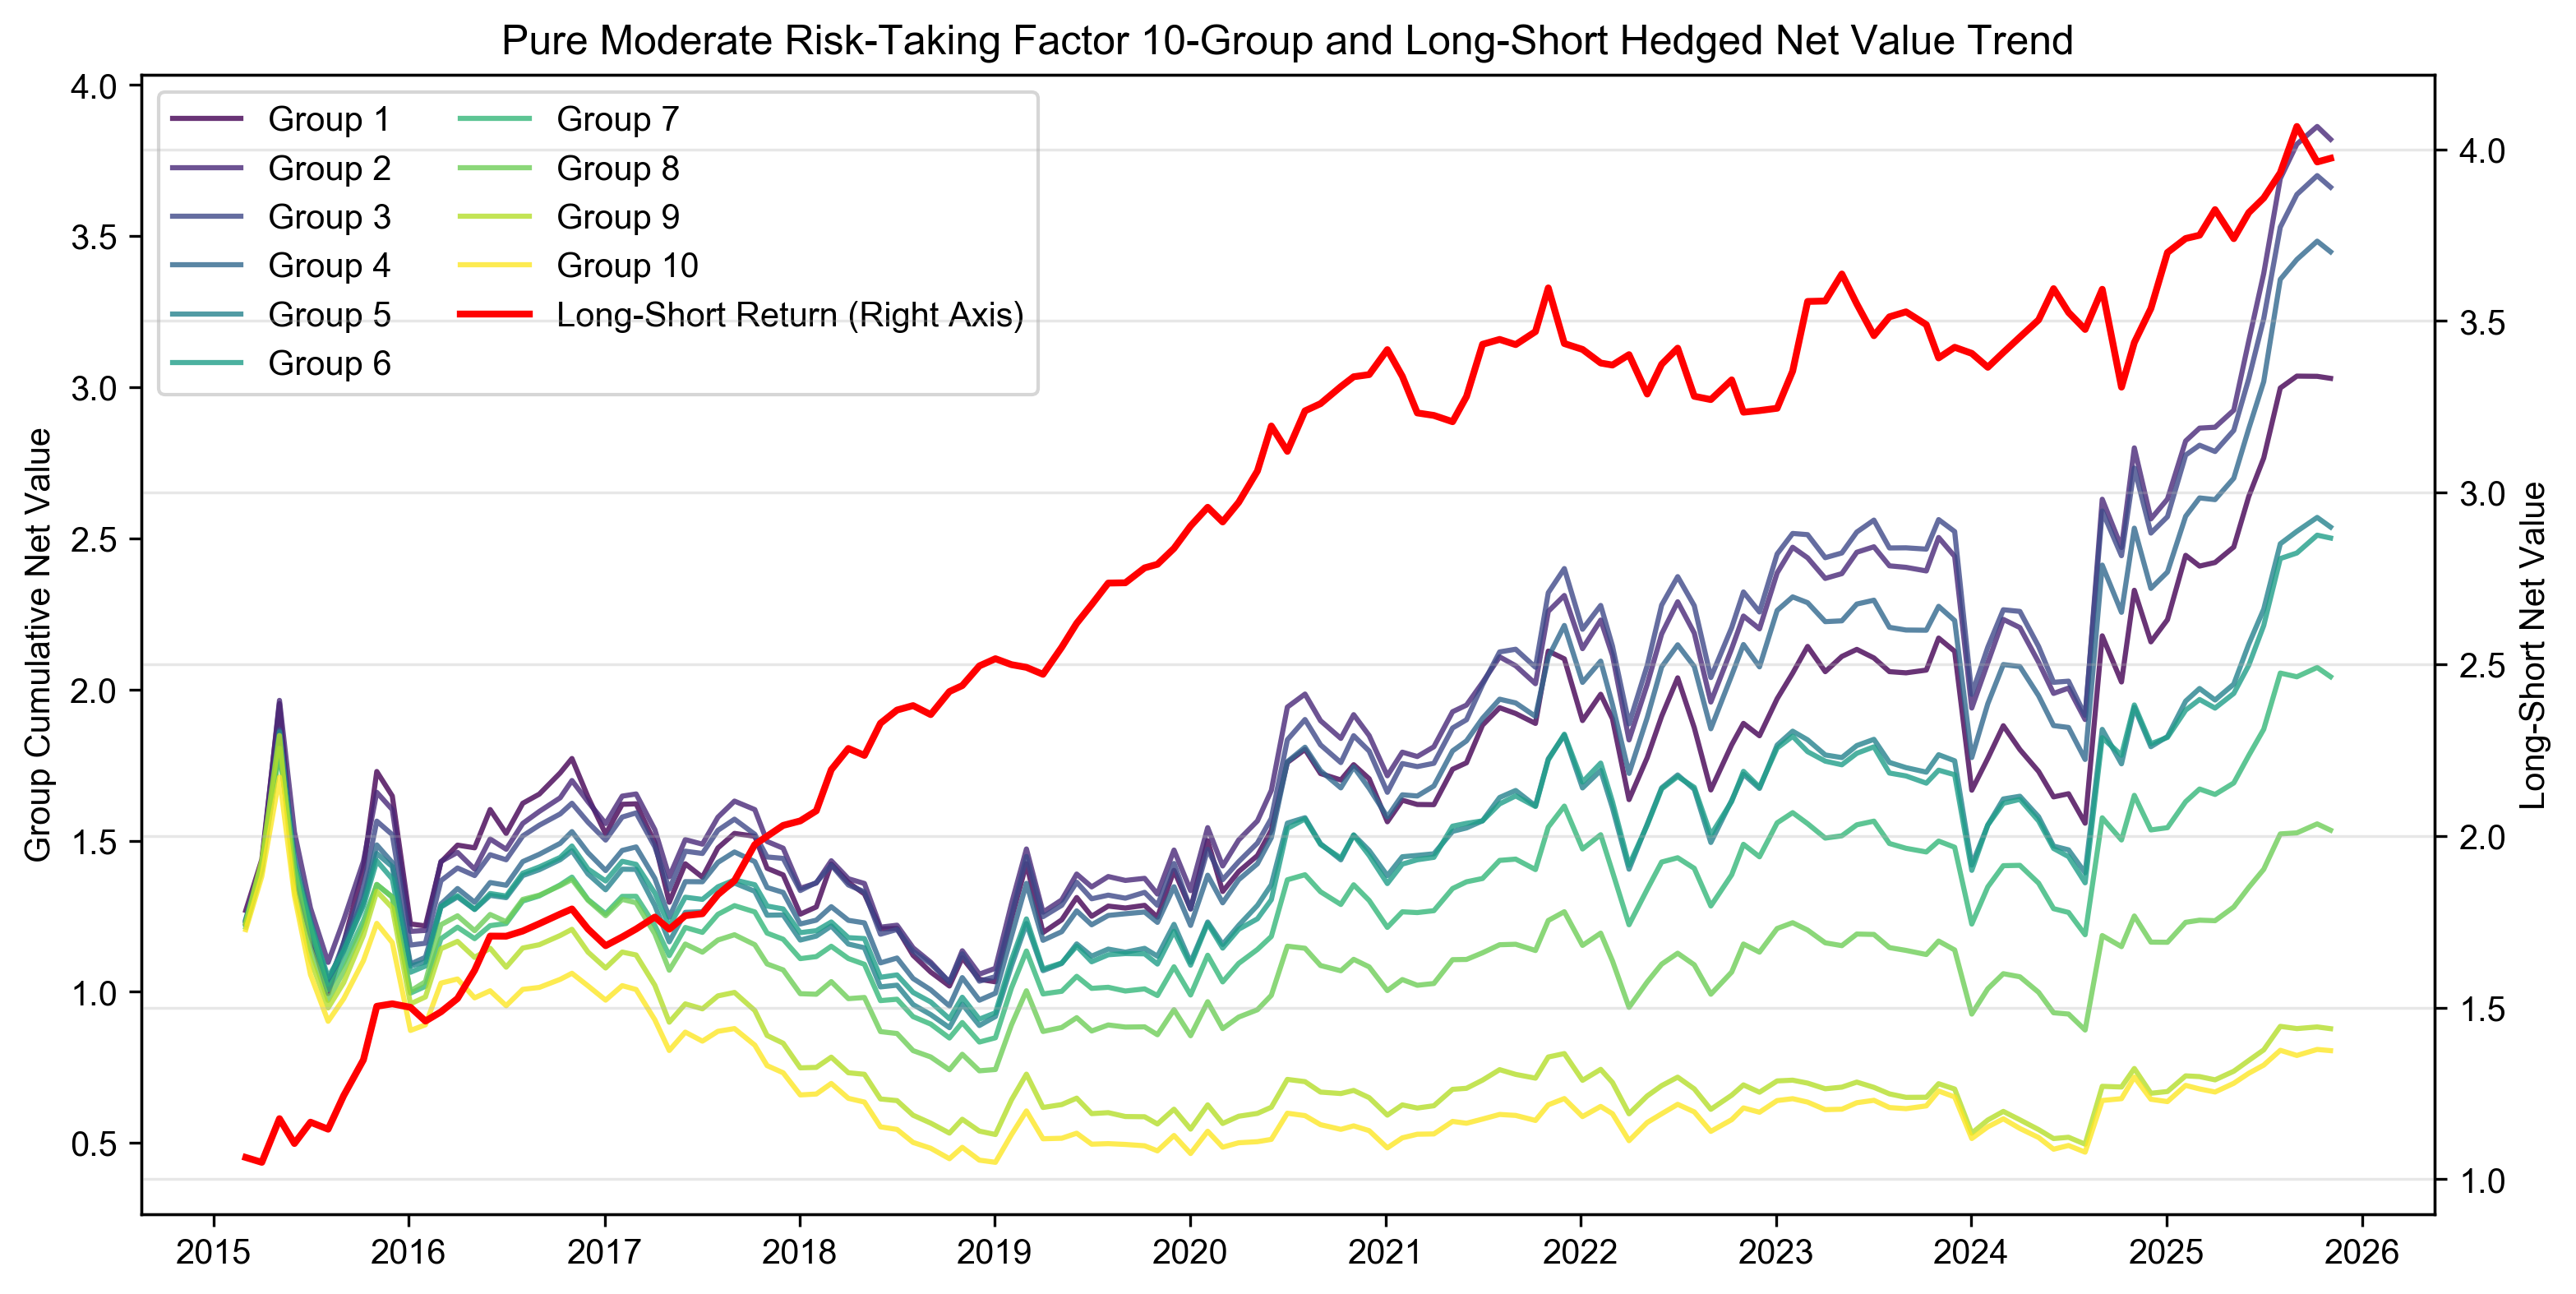

In [24]:
e8 = FactorBacktester(factor_pure_adventure, stock_daily, factor_name='Pure Moderate Risk-Taking Factor')
# Run backtest
e8.run()
summary = show_factor_metrics(e8)
display(summary)

e8.plot_performance()